![](https://www.secondwindwater.com/wp-content/uploads/2018/08/testing-water-2170x1085.jpg)

# 💧Intro
This project aims to develop a machine learning model to predict water potability based on various physical and chemical parameters.

### About Data
The dataset contains 3,276 water samples with 10 features including pH, hardness, solids, and other measurements, with a binary potability target variable.

# 💧Setup

In [1]:
# Base
import pandas as pd
import numpy as np
import random

# Modelling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer, FunctionTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, TransformerMixin

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

%config InlineBackend.figure_format='retina'
custom_params = {'grid.alpha': 0.5, 
                 'axes.titlesize': 10, 
                 #'figure.figsize': (10, 5),
                 'figure.titlesize': 14,
                 'axes.spines.top': False,   # Remove the top and right spines
                 'axes.spines.right': False, # Remove the top and right spines
                 'axes.labelsize': 8,
                 'xtick.labelsize': 8,
                 'ytick.labelsize': 8,
                 'font.size': 8              # General font size for text elements
                }
custom_palette = ['#5fa8d3', '#cae9ff', '#1b4965', '#62b6cb', '#bee9e8']
sns.set_theme(context='paper', style='whitegrid', palette=custom_palette, font='sans-serif', font_scale=1, color_codes=True, rc=custom_params)

import warnings
warnings.filterwarnings('ignore', 'use_inf_as_na option is deprecated*')


# 💧EDA
## Basic Data Understanding

In [2]:
# Import the data
water_df = pd.read_csv('/kaggle/input/water-quality-and-potability/water_potability.csv')
water_df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Create summary function 
def df_summary(df):
    # Create summary table
    sum_table = pd.DataFrame(df.dtypes, columns=['data type'])
    sum_table['%_missing'] = df.isna().sum() / len(df) * 100
    sum_table['%_duplicates'] = df.duplicated().sum() / len(df) * 100
    # Get summary stats
    desc = pd.DataFrame(df.describe(include='all').transpose())

    # Get summary stats
    sum_table['min'] = desc['min'].values
    sum_table['max'] = desc['max'].values
    sum_table['mean'] = desc['mean'].values
    sum_table['median'] = desc['50%'].values
    sum_table['std dev'] = desc['std'].values

    # Round only numeric columns
    numeric_cols = sum_table.columns.drop('data type')
    for col in numeric_cols:
        sum_table[col] = sum_table[col].round(2)

    print(f'DataFrame Shape: {df.shape}\n')
    return sum_table

# Print summary 
df_summary(water_df)

DataFrame Shape: (3276, 10)



,data type,%_missing,%_duplicates,min,max,mean,median,std dev
ph,float64,14.99,0.0,0.00,14.00,7.08,7.04,1.59
Hardness,float64,0.00,0.0,47.43,323.12,196.37,196.97,32.88
Solids,float64,0.00,0.0,320.94,61227.20,22014.09,20927.83,8768.57
Chloramines,float64,0.00,0.0,0.35,13.13,7.12,7.13,1.58
Sulfate,float64,23.84,0.0,129.00,481.03,333.78,333.07,41.42
Conductivity,float64,0.00,0.0,181.48,753.34,426.21,421.88,80.82
Organic_carbon,float64,0.00,0.0,2.20,28.30,14.28,14.22,3.31
Trihalomethanes,float64,4.95,0.0,0.74,124.00,66.40,66.62,16.18
Turbidity,float64,0.00,0.0,1.45,6.74,3.97,3.96,0.78
Potability,int64,0.00,0.0,0.00,1.00,0.39,0.00,0.49


In [4]:
water_df.groupby("Potability").apply(lambda x: x.isna().sum())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
Potability,,,,,,,,,,
0,314,0,0,0,488,0,0,107,0,0
1,177,0,0,0,293,0,0,55,0,0


>#### Considerations on Summary Statistics
>**Missing Data:**
>- `15%` in **ph** column, 
>- `5%` in **Trihalomethanes** column
>-  `~25%` in **Sulfate** column.
>
>Most of missung values belongs to `Class 0` (not-potable).

## Data Validation
Validating and handling extreme values is a critical step when working with chemical data. This initial analysis serves several purposes: it ensures data quality, highlights potential measurement or recording issues, and informs the development of a robust feature engineering strategy.

For water quality measurements I would outline between three types of extreme values:
1. **Physically Impossible Values:** violate natural laws or measurement constraints.
2. **Physically Possible but Extreme Values:** represent rare but plausible measurements.
3. **Values Outside Normal Operating Ranges:** measurements that, while theoretically valid, fall outside the ranges where derived chemical relationships remain reliable.

Given my limited domain knowledge in water quality, I will focus exclusively on identifying **Physically Impossible Values**.

In [5]:
# Check for physically impossible values
def identify_impossible_values(df):
    """
    Identifies physically impossible measurements in water quality data.
    """
    impossible_conditions = {
        'pH': (df['ph'] < 0) | (df['ph'] > 14),
        'Conductivity': df['Conductivity'] < 0,
        'Hardness': df['Hardness'] < 0
    }
    
    for feature, condition in impossible_conditions.items():
        impossible_count = condition.sum()
        if impossible_count > 0:
            print(f"{feature}: {impossible_count} impossible values found")
        else:
            print(f"{feature}: No imposible values found.")

identify_impossible_values(water_df)

pH: No imposible values found.
Conductivity: No imposible values found.
Hardness: No imposible values found.


## Data Distribution Analysis



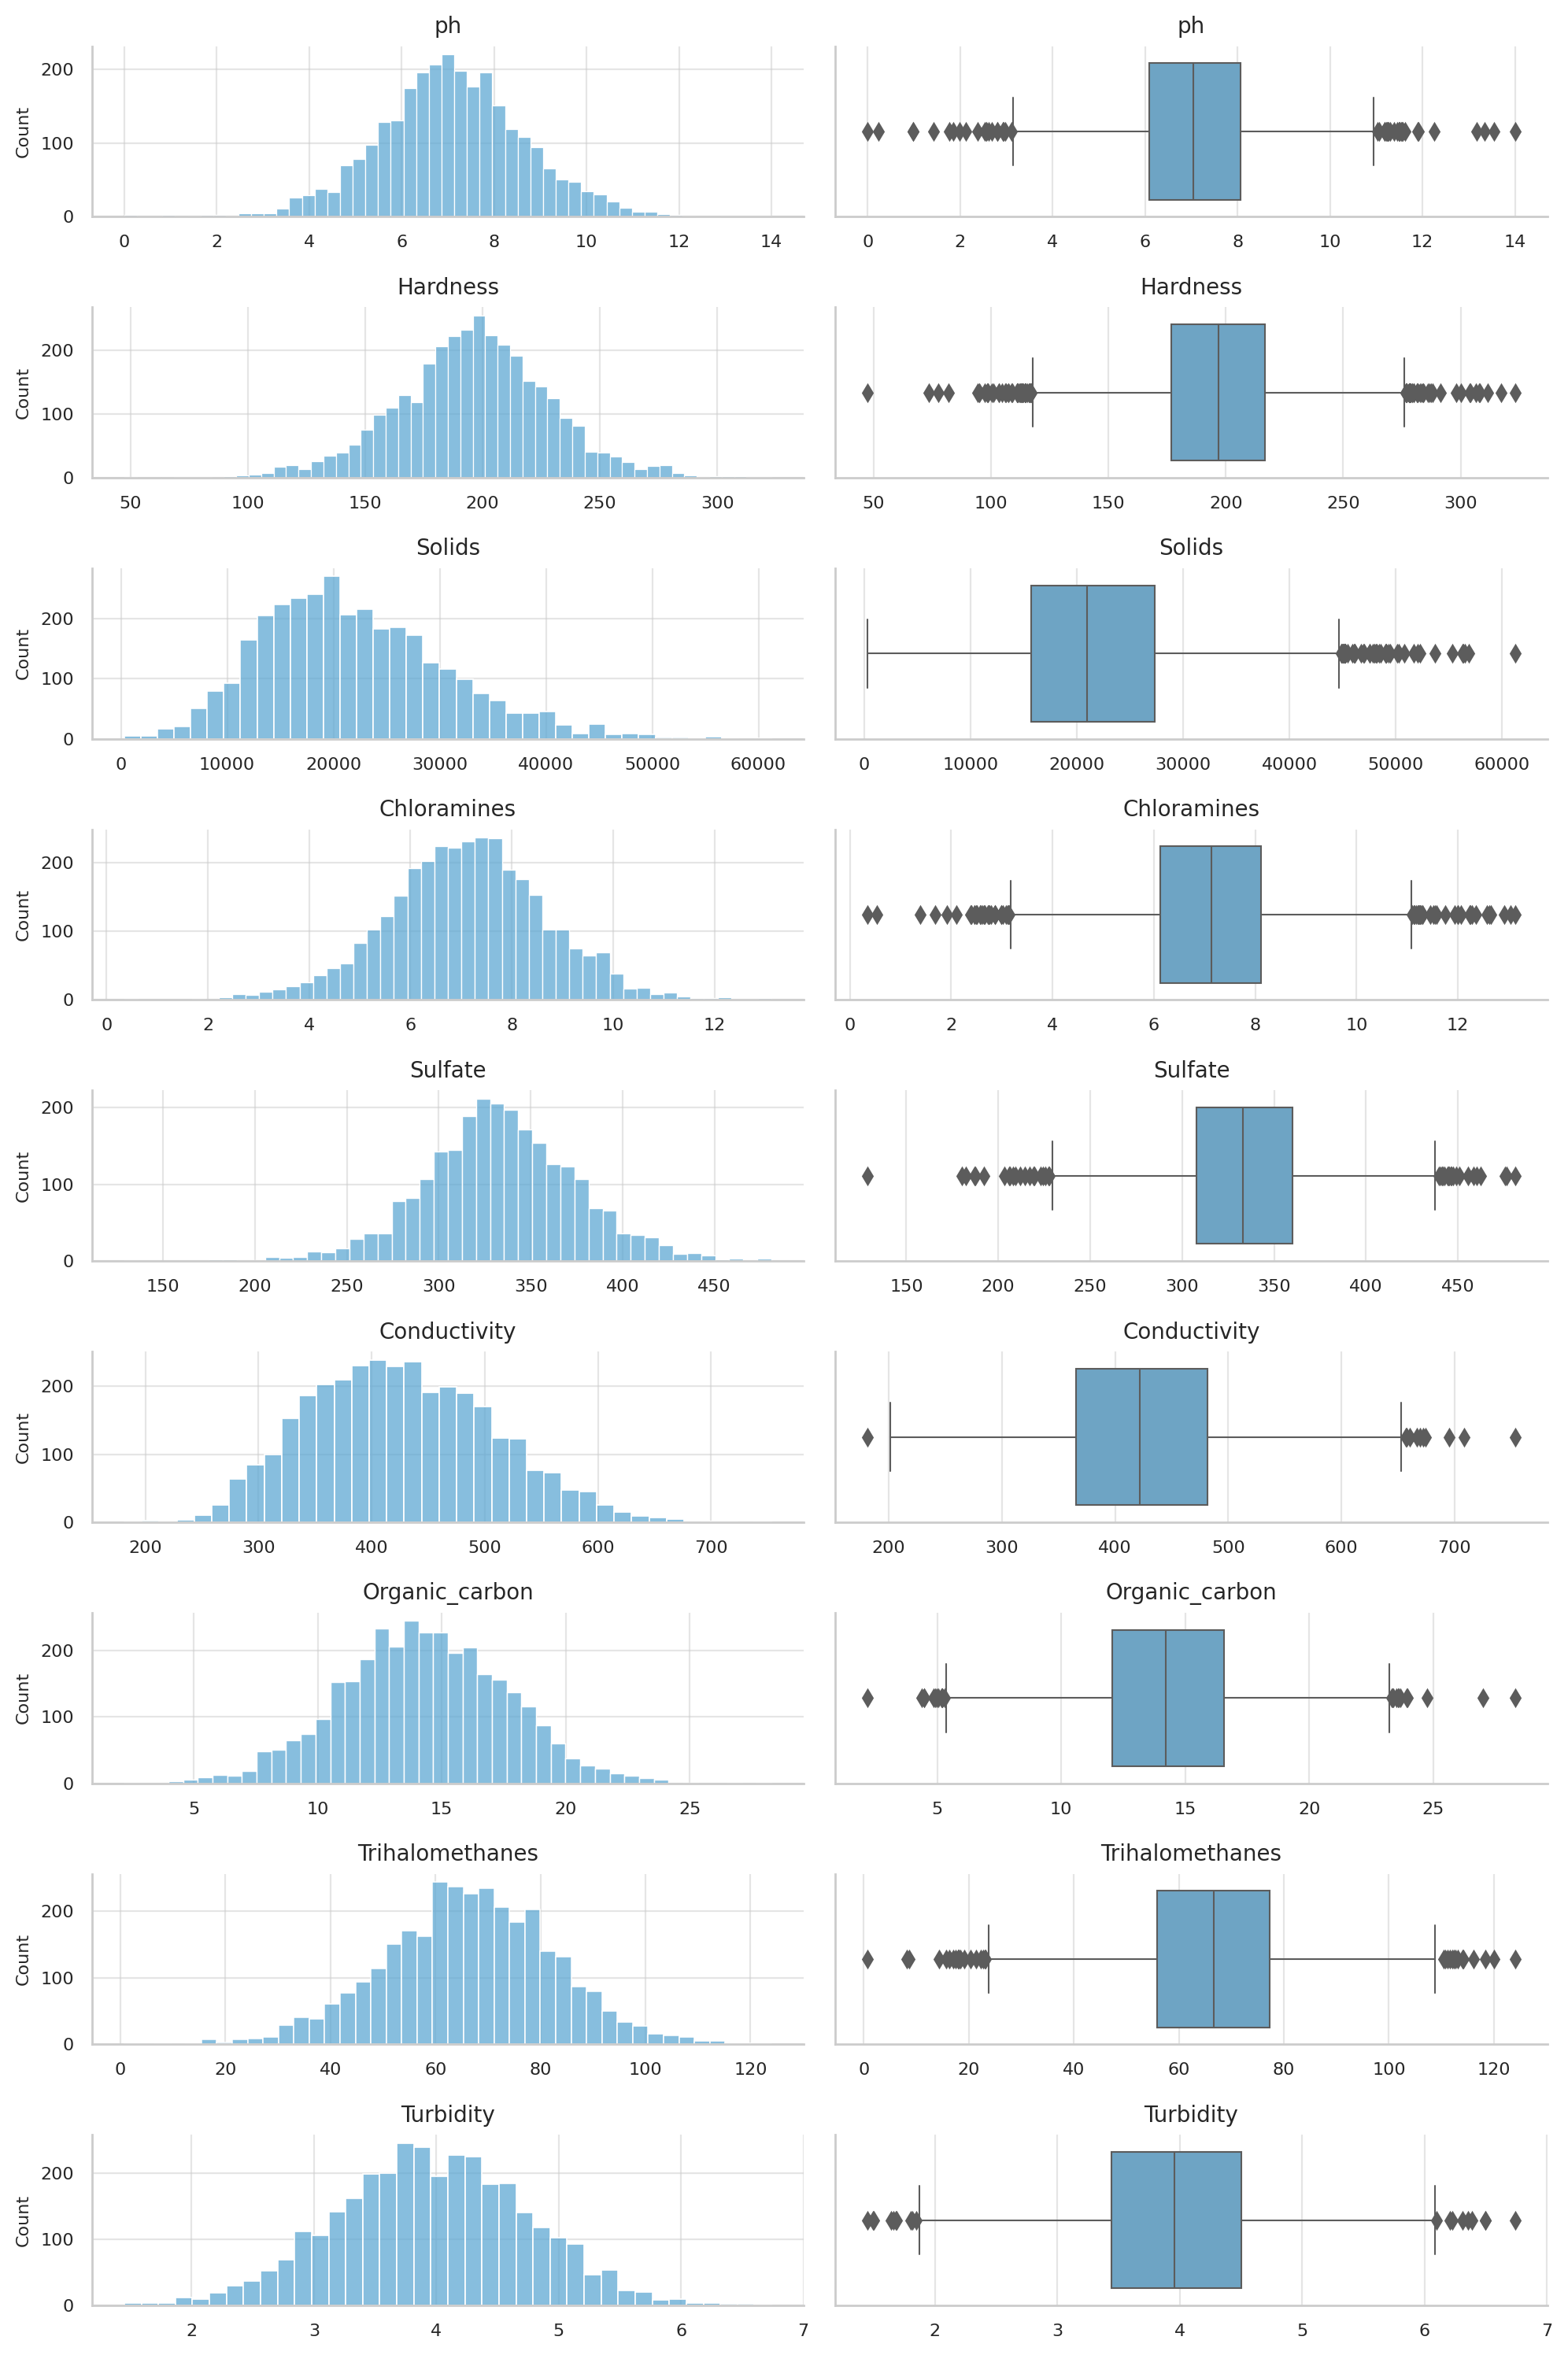

In [6]:
# Create subplot grid
fig, axes = plt.subplots(9, 2, figsize=(10, 15))

# Plot histogram & boxplot for each feature
for idx, col in enumerate(water_df.columns[:-1]):
    # Histogram
    sns.histplot(data=water_df, x=col, ax=axes[idx,0])
    axes[idx,0].set_title(col)
    axes[idx,0].set_xlabel("")

    # Boxplot
    sns.boxplot(data=water_df, x=col, ax=axes[idx,1], orient='h', linewidth=.75)
    axes[idx,1].set_title(col)
    axes[idx,1].set_xlabel("")

# Adjust layout
plt.tight_layout(h_pad=1.5, w_pad=1.5)
plt.show()

>#### Considerations on Feature Distributions
>1. **Distribution patterns**:
>    - Most features follow approximately normal distribution.
>    - `Solids`, `Organic_carbon`, and `Conductivity`  display notable right skewness.
>2. **Outliers presence**:
>    - All features contain outliers.
>    - Retention of outliers is justified as they likely represent valid extreme water quality measurements
>3. **Scale differences**:
>    - Features operate on vastly different scales (e.g., `Solids` ~20000 vs `pH` ~7)

## Class Balance

Potability
0    1998
1    1278
Name: count, dtype: int64


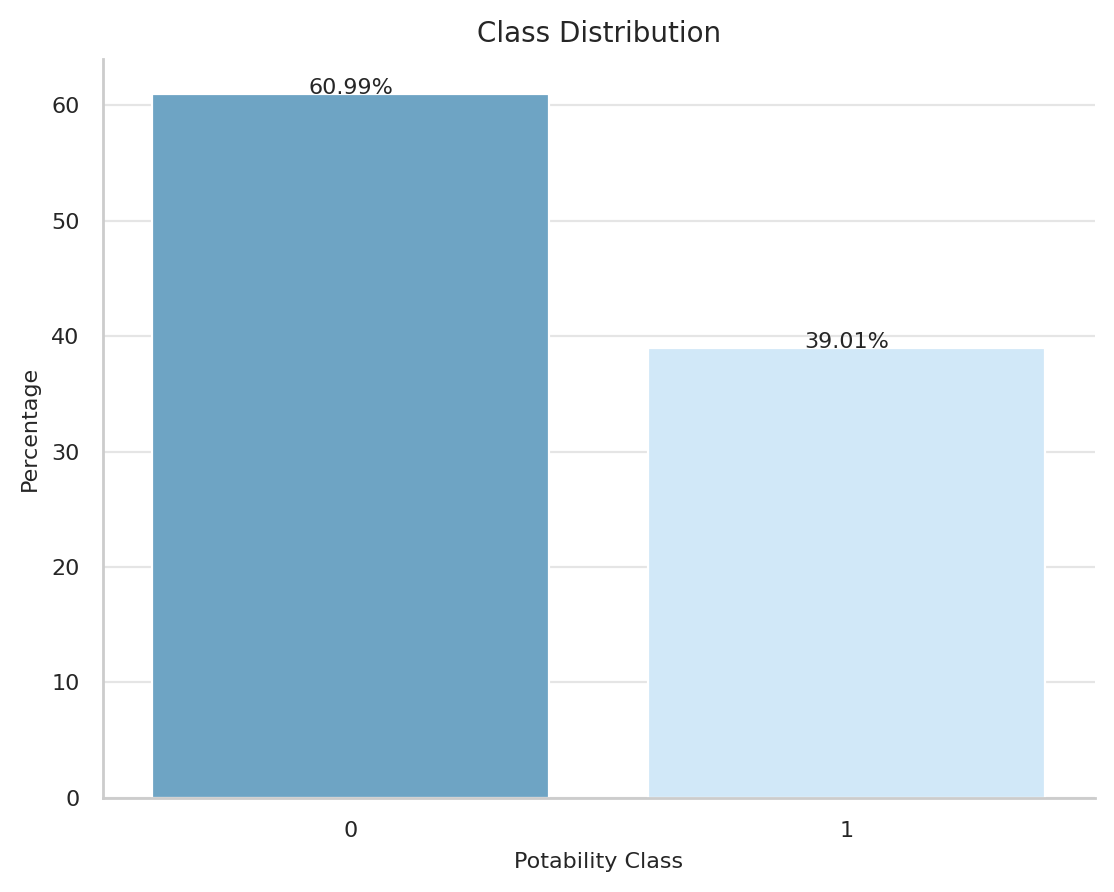

In [7]:
print(water_df['Potability'].value_counts())

# Calculate class distribution in percentage
class_dist = (water_df['Potability'].value_counts(normalize=True) * 100).round(2)

# Create figure and axes
fig, axes = plt.subplots()
# Plot class distribution
sns.barplot(x=class_dist.index, y=class_dist.values)
plt.title('Class Distribution')
plt.xlabel('Potability Class')
plt.ylabel('Percentage')
for i, v in enumerate(class_dist):
   plt.text(i, v, f'{v}%', ha='center')
plt.show()

>#### Considerations on Class Distribution
>There is significant class imbalance present in the target variable distribution (`~20%` difference).
><br>This imbalance is actually expected in real-world water quality data, as water is more often **unsafe** than **safe** in untreated samples.

## Data Relationship Analysis

### Feature Correlation Analysis (Linear Relationships)
Assess linear relationships between features to identify dependencies and enhance understanding of water quality parameters.

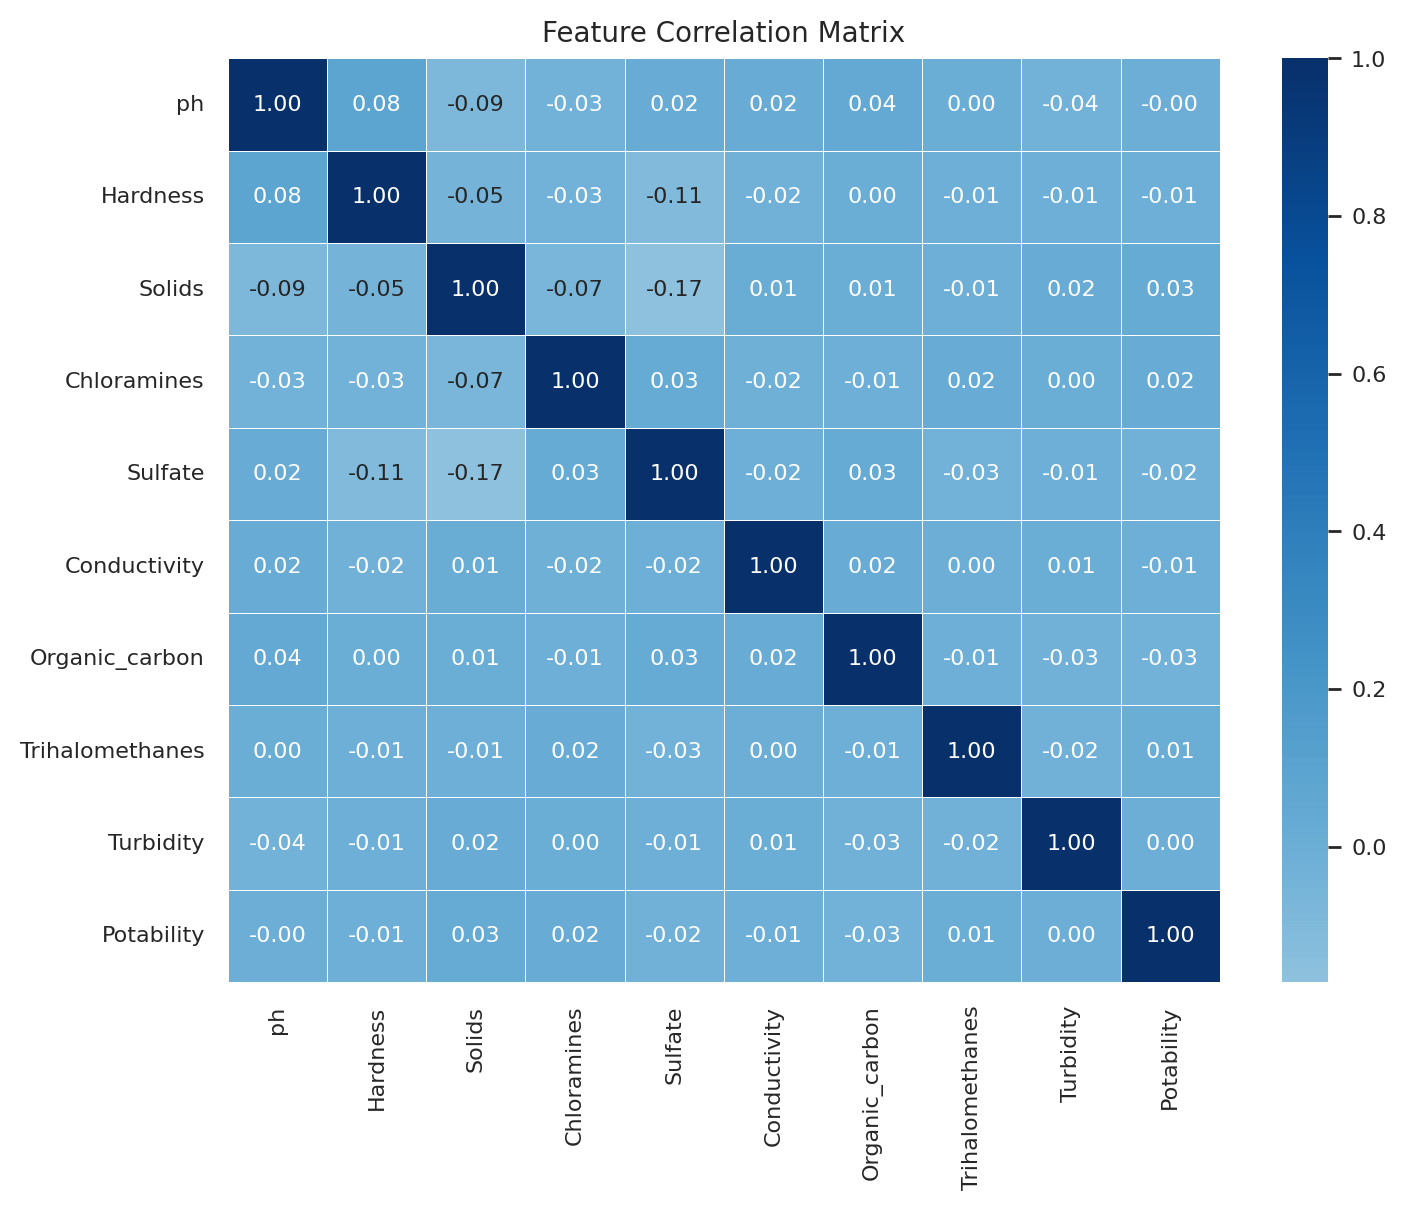

In [8]:
# Visualize correlations
fig, axes = plt.subplots(figsize=(8,6), dpi=100)
sns.heatmap(water_df.corr(), annot=True, fmt=".2f", center=0, cmap='Blues',linecolor='white', linewidths=0.2)
plt.title('Feature Correlation Matrix')
plt.show()

### Non-linear relationships
Explore non-linear dependencies between features and `Potability` to uncover complex patterns beyond linear correlation analysis.

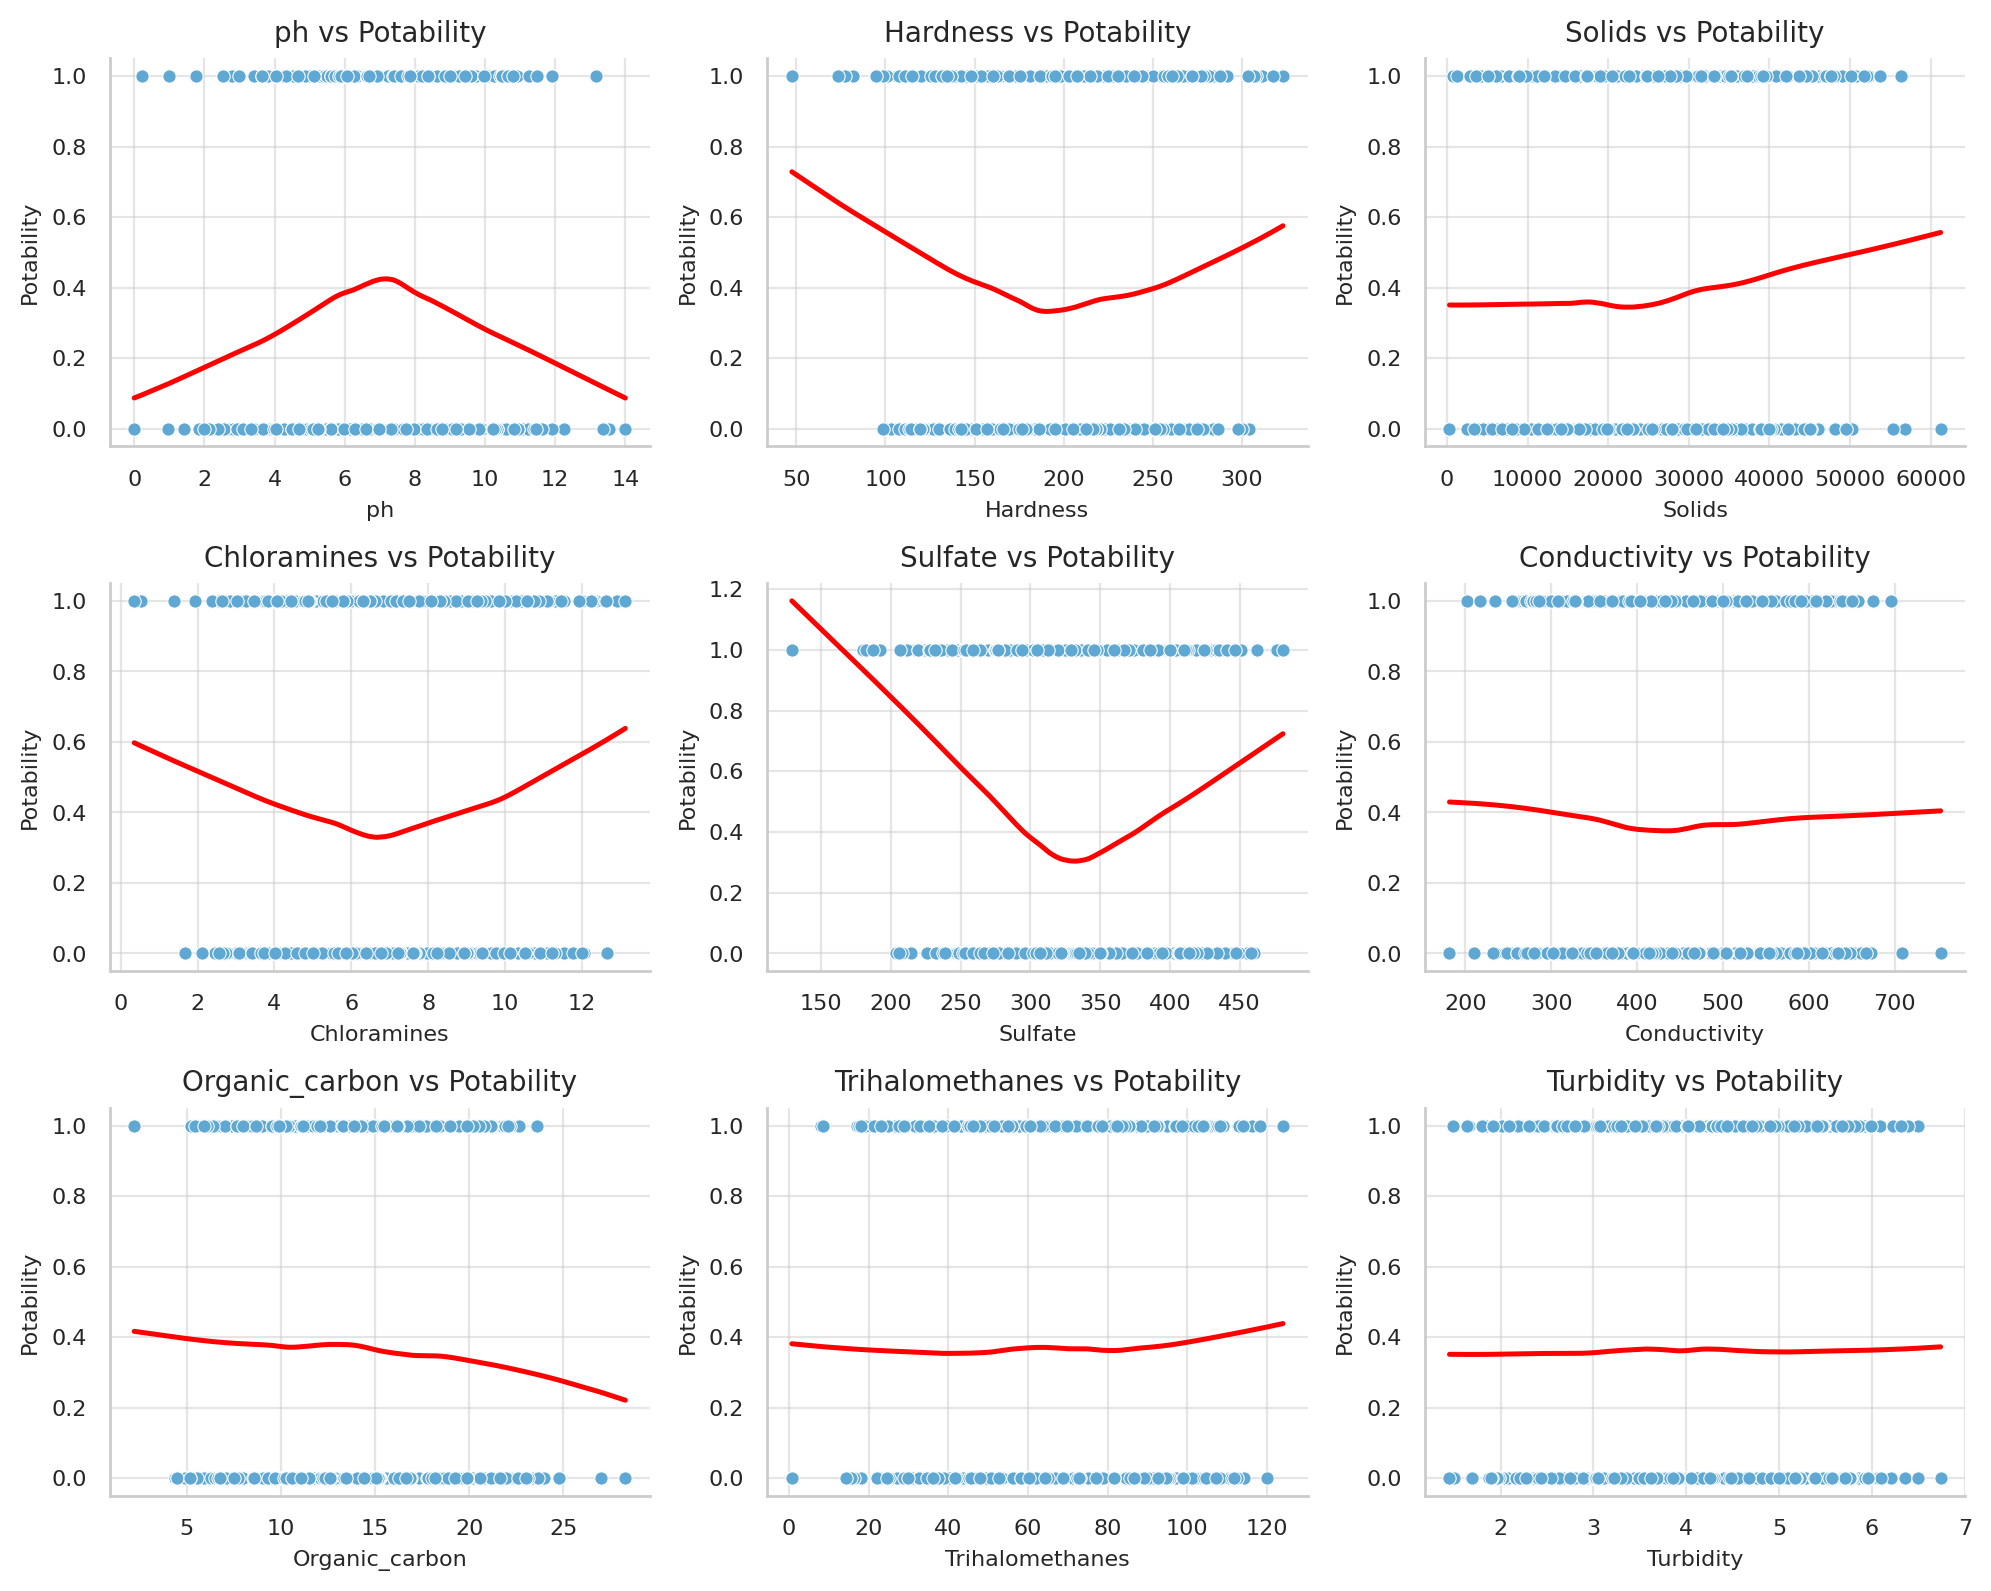

In [9]:
# Create subplot grid
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
# Flatten the 3x3 grid of axes into a 1D array for easy iteration
axes = axes.ravel()

# Loop through each feature (excluding the target 'Potability') and create scatter plots
for idx, column in enumerate(water_df.columns[:-1]):    # Exclude the last column ('Potability'
    # Plot a scatter plot for the feature against 'Potability'
    sns.scatterplot(data=water_df, x=column, y='Potability', ax=axes[idx])
    # Add a red trend line using LOWESS (locally weighted scatterplot smoothing) to capture non-linear patterns
    sns.regplot(data=water_df, x=column, y='Potability', ax=axes[idx], scatter=False, color='red', lowess=True)
    axes[idx].set_title(f'{column} vs Potability')

plt.tight_layout()
plt.show()

#### Non-linear Patterns
**pH:** U-shape points **UP** in the middle (around `7-8`):
- This means: middle values are GOOD for drinking water
- Makes sense: neutral `pH` is best for drinking water

**Hardness, Chloramines, Sulfate:** U-shape points **DOWN** in the middle:
- This means: middle values are BAD for drinking water
- Either low OR high values are better
- This is interesting and might indicate:
  - Different types of safe water (soft vs hard)
  - Multiple acceptable ranges
  - Possible interaction with other parameters

>#### Considerations on Features Relationships
>**Correlation Matrix:** The correlation matrix reveals **minimal interdependence** between features (strongest correlation being `|r| = 0.17` between `Solids` and `Sulfate`) and target variable `Potability` (all `|r| < 0.1`). This lack of strong correlations suggests each water quality parameter provides unique information for classification.
>
> 
>**Non-linear relationships:** The visualizations reveal distinct **non-linear patterns**, particularly in `pH`, `Hardness`, `Chloramines`, and `Sulfate` relationships with potability. These complex interactions justify using algorithms capable of capturing non-linear relationships and possible using feature engineering technics.


## High-dimensional Feature Space Analysis
**t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a technique that helps us visualize high-dimensional data in 2D or 3D space. It is like taking a complex 9-dimensional map of the water samples (9 features) and carefully squishing it down to 2 dimensions while trying to preserve the relationships between samples.
- It helps visualize natural groupings in the data
- Shows if classes (potable/non-potable) form distinct clusters
- Reveals potential outliers or unusual patterns



>Clusters -> groups of similar water samples.
<br>Scattered points -> unusual or isolated samples

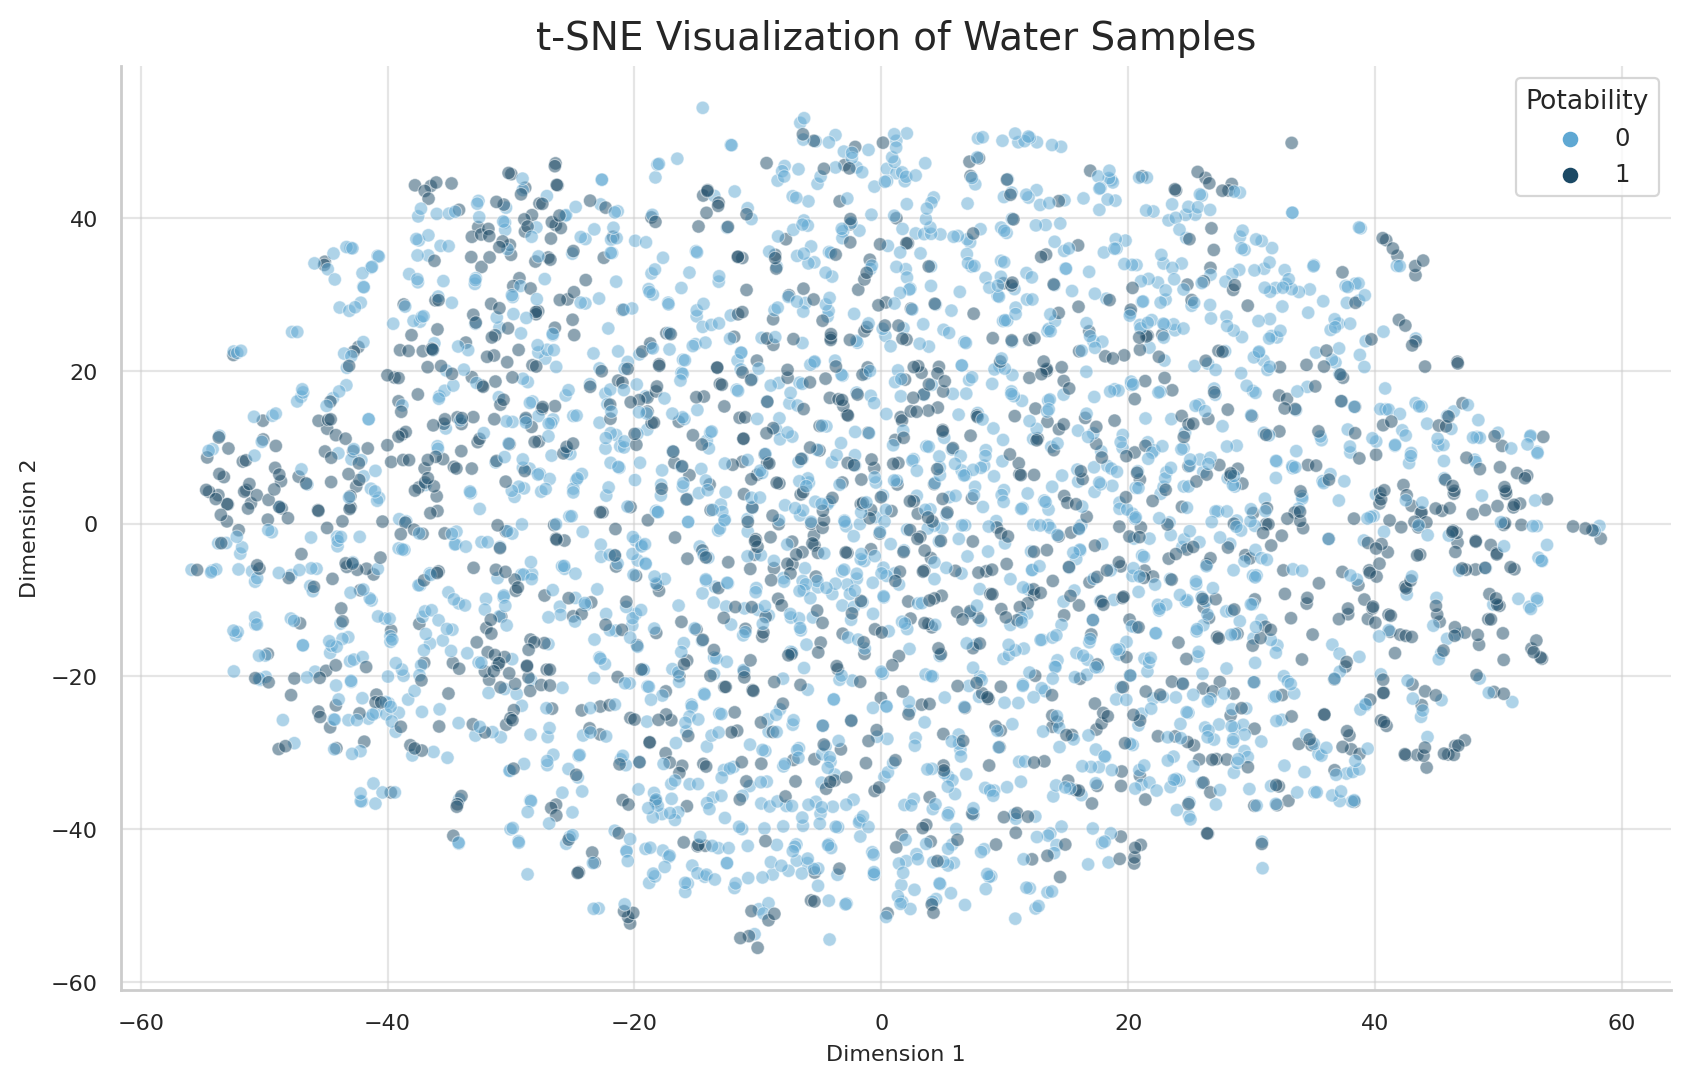

In [10]:
# Handle missing values and scale features
X_tsne_imputed = KNNImputer(n_neighbors=5, weights='distance', metric='nan_euclidean', 
                            add_indicator=True).fit_transform(water_df.drop('Potability', axis=1))
X_tsne_scaled = RobustScaler().fit_transform(X_tsne_imputed)
y_tsne = water_df['Potability']

# Create t-SNE object
tsne = TSNE(n_components=2, random_state=42)
# Apply t-SNE for dimensionality reduction
X_tsne = tsne.fit_transform(X_tsne_scaled) # X_tsne is a 2D array(each row = one water sample)  

# Convert t-SNE results and labels into a DataFrame for easier plotting
tsne_df = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
tsne_df['Potability'] = y_tsne  # Add y-labels to the DataFrame

# Plot t-SNE 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Potability', 
                palette={0: custom_palette[0], 1: custom_palette[2]}, 
                alpha=0.5)
plt.title('t-SNE Visualization of Water Samples', fontsize=14)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()


>**Considerations on Feature Space Analysis**
>1. **Complex Class Boundaries:** The significant overlap between `potable` and `non-potable` samples indicates a complex classification problem requiring sophisticated modeling approaches which can handle it (possibly `Random Forest`).
>2. **Data Distribution Pattern:** The scattered distribution without clear clusters suggests water potability depends on subtle combinations of multiple features rather than individual parameters.
>   
>Looks like the relationship between water parameters and `potability` **isn't just complex - it's likely that some water samples with very similar parameters have different potability outcomes** due to factors which can't be measured. <br>It potentailly could be the result of human factor, or some other indicators not mentioned in the dataset, as I can be sure in data source.

----

# 💧Model Selection: Random Forest(RF) for Water Classification
Given the characteristics of the dataset and the insights derived from EDA, `Random Forest` emerges as a well-suited algorithm for the water classification task. <br>This decision is supported by several key factors:
- **Complex Class Boundaries:** The significant overlap observed between potable and non-potable samples in the `t-SNE` visualization suggests that the problem requires a model capable of capturing complex classification boundaries. `Random Forest`, with its ensemble of decision trees, excels at handling such complexities.
- **Non-uniform Distributions**: density plots showed non-normal distributions for several features (like `pH`). `Random Forest` accommodates these distributions effectively by leveraging binary splits, enabling it to adapt to the underlying data without relying on assumptions of normality.
- **Feature Independence**: The correlation heatmap reveals that the features are largely uncorrelated, indicating independent contributions to the classification process. `Random Forest` naturally identifies and prioritizes important features through its tree-based structure, making it highly effective for such data.
- **Non-linear relationships**: `RF` ability to model complex, non-linear relationships aligns well with the dataset, where interactions between features and the target variable may not follow simple linear trends. Its ensemble approach captures these patterns by combining diverse decision trees.
- **Robustness to Scale and Outliers**: The dataset includes features with vastly different scales (`Solids` vs. `pH`) and potential outliers. `Random Forest` is inherently scale-invariant and less sensitive to outliers, ensuring that these characteristics do not adversely affect its performance.
- **Missing values**: While `Random Forest` can process missing values natively, preprocessing with imputation techniques (e.g., `SimpleImputer` or `KNNImputer`) can further improve data quality and model performance.

## Assumptions
`Random Forest` operates with relatively few assumptions, which is one of its key advantages. However, to ensure optimal performance, the following considerations should be kept in mind:

1. **Preprocessing Missing Values:** While `RF` can handle missing values, preprocessing through imputation ensures cleaner input data and more reliable results.
2. **Feature Engineering:** `RF` benefits from features that carry meaningful information, making exploratory data analysis and thoughtful feature selection crucial steps.

-----

# 💧Model Development
The project adopts a phased approach to ensure systematic development and validation of the water potability prediction model:
1. **Baseline Model & Analysis:**
   - Quickly identify key patterns and challenges
   - Understand feature importance and data quality issues
   - Build and evaluate the model
   - Guide decisions for feature engineering and model improvements


2. **Advanced Model:**
   - Apply insights gained from the Baseline Model
   - Leverage domain knowledge to create new features or transform existing ones
   - Implement sophisticated techniques
   - Fine-tune hyperparameters
   - Build and evaluate the model
   - Compare performance with Baseline Model

This iterative approach will help to validate improvements and to be sure model changes are justified by data insights.

----

# 💧Baseline Model
### Data Split

In [11]:
# Prepare data
X_base = water_df.drop('Potability', axis=1)
y_base = water_df['Potability']

# Split data into train and test sets
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, 
    test_size=0.2, 
    random_state=42,
    stratify=y_base    # This ensures same class proportions in train and test
)

## Model Pipeline


In [12]:
# Create pipeline
baseline_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5, weights='distance', add_indicator=True)), # Handle missing values using KNN approach
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        bootstrap=True,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1))
])

# Define parameter search space for RF optimization
param_grid = {
    'rf__n_estimators': [400, 500],        # number of trees
    'rf__max_depth': [4, 6],               # max depth of each tree
    'rf__min_samples_split': [15, 20],     # min samples to split a node
    'rf__min_samples_leaf': [8, 10, 12],   # min samples in a leaf
}

# Setup RandomizedSearchCV for efficient hyperparameter tuning
random_search = GridSearchCV(
    baseline_pipeline,
    param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='f1'    # Optimize both `F1-score` and `precision`
)

##  Baseline Model Evaluation

In [13]:
def evaluate_model(best_model, X_train, y_train, X_test, y_test):
    """
    Evaluate model performance including classification metrics, calibration, 
    and confidence distribution.
    
    Args:
        model: Trained model with predict and predict_proba methods
        X_train, y_train: Training data and labels
        X_test, y_test: Test data and labels
    """
    # Get predictions for both sets
    y_train_pred = best_model.predict(X_train)
    y_train_prob = best_model.predict_proba(X_train)[:, 1]   # Probabilities for positive class
    
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]     # Probabilities for positive class

    performance_metrics = {
        'train_report': classification_report(y_train, y_train_pred),
        'test_report': classification_report(y_test, y_test_pred)
    }
    
    # Print classification metrics
    print("\nTraining Set Performance:")
    print(performance_metrics['train_report'])
    print("\nTest Set Performance:")
    print(performance_metrics['test_report'])
    
    # Analyze prediction confidence (apply function)
    analyze_confidence_distribution(y_train_prob, y_test_prob)

    return y_train_prob, y_test_prob, performance_metrics


def analyze_confidence_distribution(train_prob, test_prob):
    """
    Analyze and visualize model confidence in predictions.
    Args:
        train_prob: Predicted probabilities for training set
        test_prob: Predicted probabilities for test set
    """
    # Plot probability distributions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for idx, (label, prob) in enumerate([("Training Set", train_prob), ("Test Set", test_prob)]):
        ax = ax1 if idx == 0 else ax2
        # Use seaborn's histplot with stat='percent'
        sns.histplot(data=prob, bins=np.linspace(0, 1, 11), 
                    stat='percent',     # Converts to percentages
                    ax=ax,
                    color=custom_palette[2])
        
        ax.set_xlabel('Predicted probability of being Potable (Class 1)')
        ax.set_ylabel('Percentage of samples (%)')
        ax.set_title(f'{label} Probability Distribution')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
        
    # Print confidence level analysis
    confidence_levels = {
        'High (>0.7)': (lambda p: p > 0.7),
        'Medium (0.5-0.7)': (lambda p: (p > 0.5) & (p <= 0.7)),
        'Low (<0.5)': (lambda p: p <= 0.5)
    }

    for label, probabilities in [('Train Set', train_prob), ('Test Set', test_prob)]:
        print(f"\n{label} Confidence Distribution:")
        for level, condition in confidence_levels.items():
            pct = np.mean(condition(probabilities))
            print(f"{level}: {pct:.1%}")

Training model with GridSearchCV...

Best parameters found:
{'rf__max_depth': 6, 'rf__min_samples_leaf': 12, 'rf__min_samples_split': 15, 'rf__n_estimators': 500}

Evaluating model performance...

Training Set Performance:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82      1598
           1       0.72      0.66      0.69      1022

    accuracy                           0.77      2620
   macro avg       0.76      0.75      0.75      2620
weighted avg       0.77      0.77      0.77      2620


Test Set Performance:
              precision    recall  f1-score   support

           0       0.68      0.72      0.70       400
           1       0.52      0.47      0.50       256

    accuracy                           0.63       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.62      0.63      0.62       656



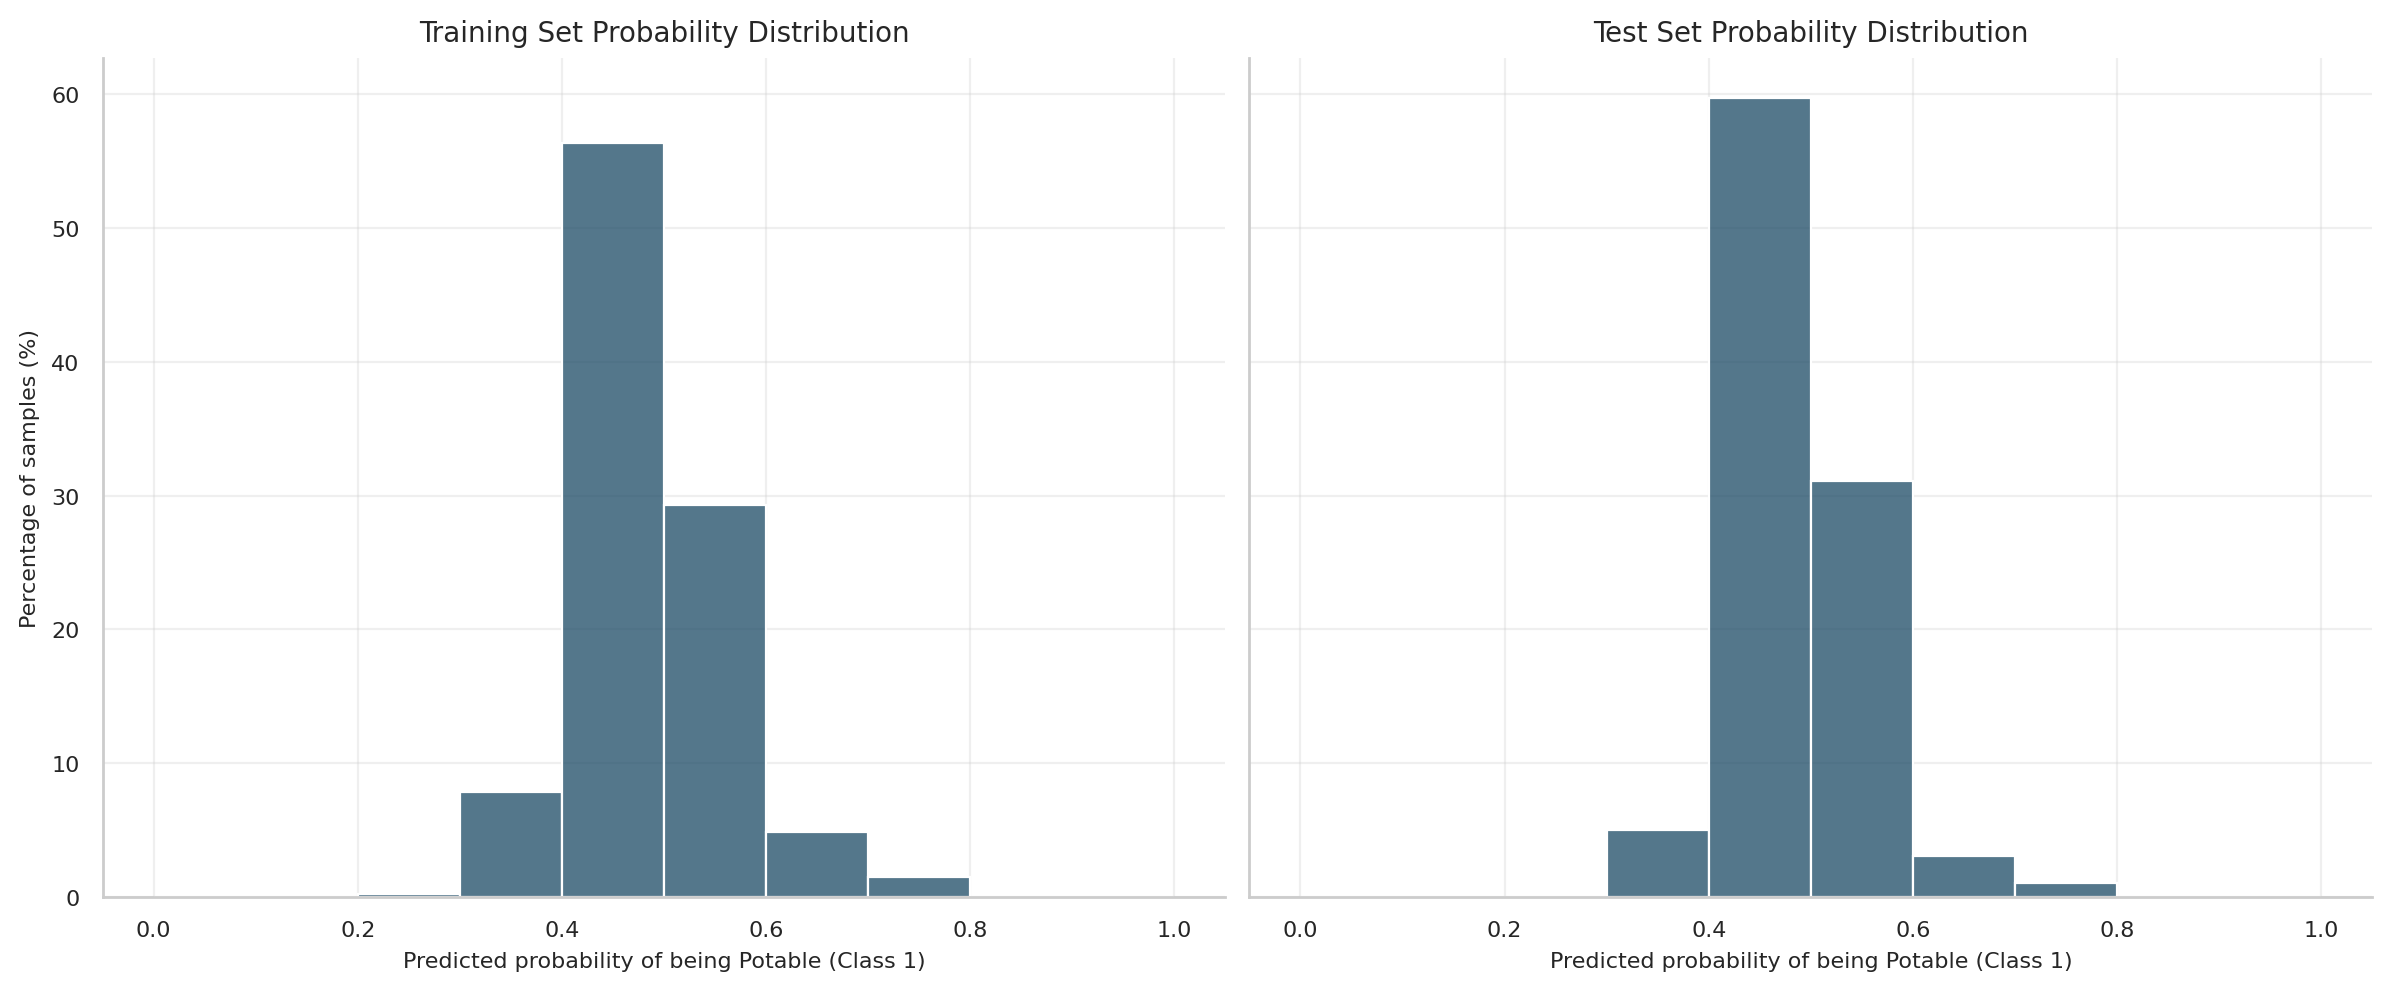


Train Set Confidence Distribution:
High (>0.7): 1.5%
Medium (0.5-0.7): 34.2%
Low (<0.5): 64.4%

Test Set Confidence Distribution:
High (>0.7): 1.1%
Medium (0.5-0.7): 34.1%
Low (<0.5): 64.8%


In [14]:
# Fit the model
print("Training model with GridSearchCV...")
random_search.fit(X_train_base, y_train_base)

# Retrieve the model with the best hyperparameters found during the random search
best_baseline_model = random_search.best_estimator_
print("\nBest parameters found:")
print(random_search.best_params_)

# Model Evaluation
print("\nEvaluating model performance...")
y_train_base_prob, y_test_base_prob, baseline_performance_metrics = evaluate_model(best_baseline_model, X_train_base, 
                                                                                   y_train_base, X_test_base, y_test_base)

>#### Considerations on Model Performance
>**The model achieves an accuracy of 64%, which is relatively modest.**
>- High recall (`0.47`): Identifies `47%` of potable water samples.
>- Lowe precision (`0.52`): Predictions of potable water are not highly reliable.
>- Prediction Behavior: Tends to make more aggressive classifications.
>  
> **Performance Summary Based on Probability Distributions**
> 1. Model Confidence:
>    - Strongly skewed toward low-confidence predictions (65% low, 34% medium, 1% high).
>    - Confidence distributions are nearly identical between training and test sets.
>    - Most predictions fall within the 0.4–0.5 probability range.
> 2. Key Issues:
>    - The model exhibits weak predictive confidence, with very few high-certainty predictions.
>    - Difficulty in clearly differentiating between classes.
>
>These findings suggest that while the model is stable, it lacks predictive strength. Enhancing feature engineering or refining the model architecture may improve performance.


>#### Considerations on Prediction Confidence
The model exhibits a significant lack of confidence in its predictions, suggesting that calibration could improve reliability. In particular, using `CalibratedClassifierCV` may be beneficial for the following reasons:
>1. Compressed Probability Range:
>     - Predictions are heavily concentrated in the mid-range (0.4–0.5) rather than spanning the full 0–1 scale.
>     - Calibration can help redistribute probabilities to better reflect true likelihoods.
>2. Safety-Critical Application (Water Potability):
>     - Well-calibrated probabilities are essential for informed decision-making.
>     - Different probability thresholds may be required for different use cases (e.g., stricter thresholds for declaring water potable).
>3. Impact of Class Imbalance:
>     - The model is exposed to more non-potable samples, which may skew probability estimates.
>     - Calibration can help adjust for this bias, improving predictive reliability.
>
>Since `Random Forests` aggregate predictions from multiple trees, they can sometimes be poorly calibrated. Addressing this issue could enhance model confidence and decision-making effectiveness.

## Feature Importance in Random Forest
Using **Permutation Importance** instead of built-in `feature_importance_` is more reliable as it shows how much model performance drops when each feature is randomly shuffled.
- The values represent percentage decrease in model performance when each feature is permuted.
- Error bars show the stability of importance estimates

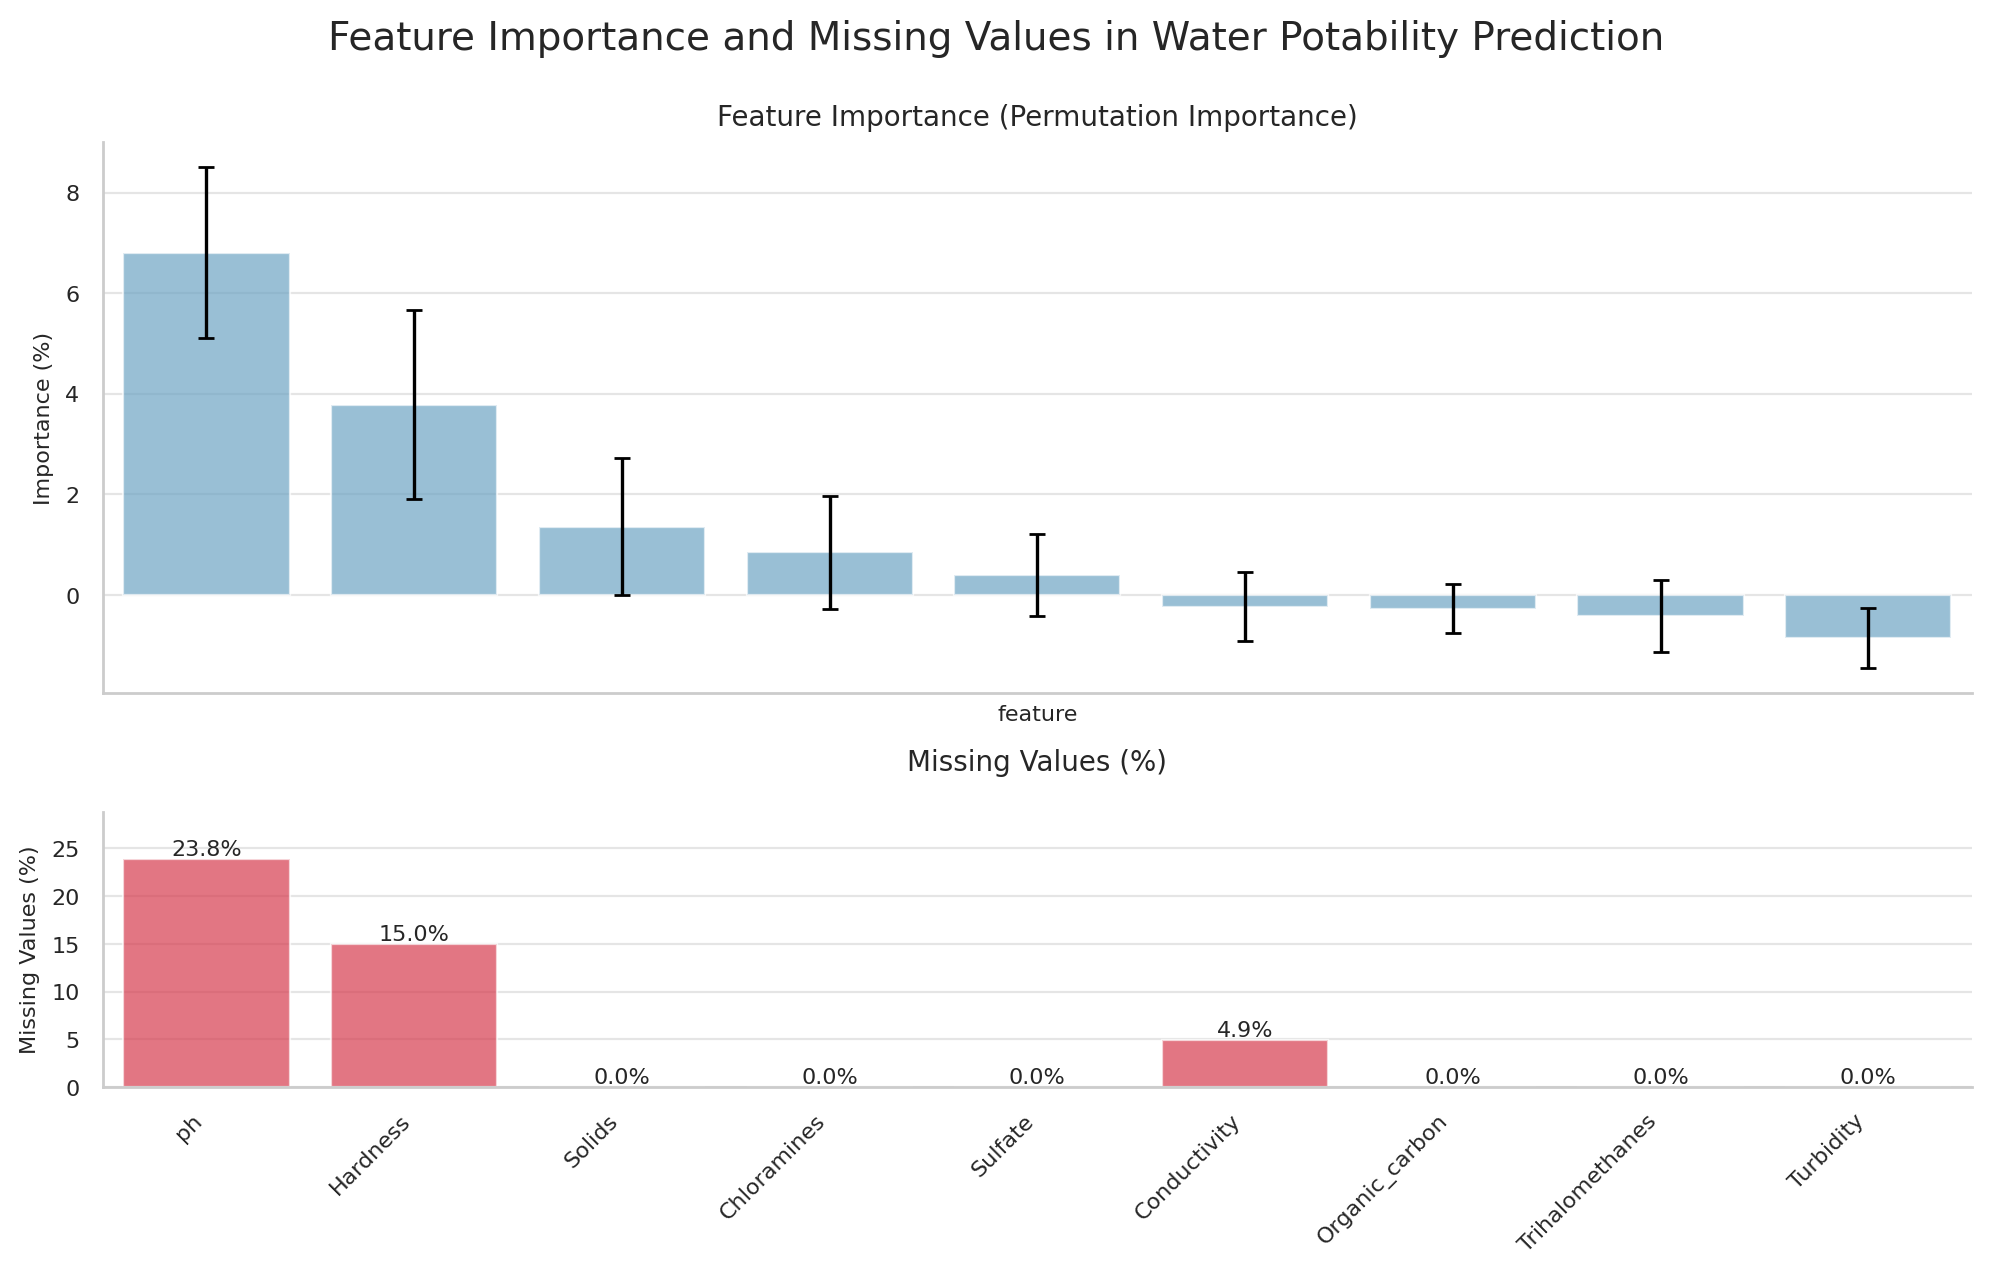

In [15]:
def analyze_feature_importance_and_completeness(model,df, X_test, y_test):
    """Analyzes feature importance using permutation importance and missing value percentages."""
    
    # Step 1: Calculate feature importance using permutation importanc
    result = permutation_importance(
        best_baseline_model,
        X_test, 
        y_test, 
        n_repeats=10, 
        random_state=42, 
        scoring='f1'
    )
    
    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance': result.importances_mean,        # Average importance over `n_repeats`
        'importance_std': result.importances_std,     # Standard deviation
        'importance_percentage': result.importances_mean * 100
    }).sort_values('importance', ascending=False)
    
    # Step 2: Compute missing value percentages
    missing_pct = df.isna().sum() / len(df) * 100
    missing_pct = missing_pct[importance_df['feature']]  # Align with sorted features

    # Step 3: Plot feature importance and missing values
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
    
    # Feature Importance Plot
    sns.barplot(data=importance_df, x='feature', y='importance_percentage', ax=ax1, color=custom_palette[0], alpha=0.7)
    ax1.set_ylabel('Importance (%)')
    ax1.set_title('Feature Importance (Permutation Importance)')
    ax1.errorbar(range(len(importance_df)), importance_df['importance_percentage'], 
                 yerr=importance_df['importance_std'] * 100, fmt='none', color='black', capsize=3)  # Add error bars

    # Missing Value Plot
    sns.barplot(x=X_test.columns, y=missing_pct, ax=ax2, color='#ef233c', alpha=0.7)
    ax2.set_ylabel('Missing Values (%)')
    ax2.set_title('Missing Values (%)', pad=15)
    ax2.set_ylim(0, max(missing_pct)+5)
    for i, v in enumerate(missing_pct):
        ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

    # Formatting
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout() 
    # Replace fig.suptitle line with:
    fig.suptitle('Feature Importance and Missing Values in Water Potability Prediction', y=1.05)
    plt.show()


# Apply the function
analyze_feature_importance_and_completeness(best_baseline_model, water_df, X_test_base, y_test_base)

>#### Considerations on Feature Importance
>`Sulfate` and `ph` appeared to be two most important features in potability prediction. At the same time, these two features share lidership in containing missing values.
><br>This is a strong signal to:
>    -  Be careful choosing the **imputation technique**.
>    -  Possibly apply feature engineering.

### Analysis of Contradictions in Water Potability Classification
In water quality analysis, **similar samples can often have different potability labels** due to complex decision boundaries, overlapping feature distributions, and gray areas in standards. 
<br>However, estimating the volume of such cases can be helpful for further refinement strategies.

In [16]:
# Find similar samples with different potability labels
def find_contradictions_in_data(X, y, n_neighbors=5):    # 5 neighbors, like in previous model training
    """
    Find water samples that have similar chemical properties but different potability labels.
    Parameters:
    -----------
    X : array-like of shape (n_samples, n_features)
        Water quality measurements (pH, hardness, etc.)
    y : array-like of shape (n_samples,)
        Potability labels (0 for non-potable, 1 for potable)
    n_neighbors : int, default=3
        Number of neighbors to consider for each sample
        
   Returns:
    --------
    X_imputed : array-like
        Data after imputation.
    X_scaled : array-like
        Standardized data for fair distance comparison.
    missing_mask : array-like of bool
        Mask of missing values in the original data.
    """

    def preprocess_data(X):
        # Standardize features for fair distance comparison
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)             # Learns parameters AND transform data
        # Fill missing values using KNN
        imputer = KNNImputer(n_neighbors=n_neighbors)  # n_neighbors same as in pipeline
        X_imputed = imputer.fit_transform(X_scaled)
        
        return X_imputed, X_scaled
        
    # Preprocess data: handle missing values and scale features
    X_imputed, X_scaled = preprocess_data(X)
    
    # Find nearest neighbors for each sample
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(X_imputed)
   
    # Get distances and indices of nearest neighbors for each sample
    distances, indices = nn.kneighbors(X_imputed)
    
    # Detect contradictions where similar samples have different labels
    contradictions = []
    for i in range(len(X)):
        neighbors_labels = y[indices[i]]     # Labels of neighboring samples
        neighbors_idxs = indices[i]          # Indices of neighboring samples
        
        # Check if neighbors have differing labels
        if len(set(neighbors_labels)) > 1:
            main_label = y[i]
            # Count neighbors with labels different from the current sample
            different_labels = sum(1 for label in neighbors_labels if label != main_label)
            contradiction_percentage = (different_labels / n_neighbors) * 100
            # Save contradiction details 
            contradictions.append({
                'sample_idx': i,                         # Index of current sample
                'sample_label': y[i],                    # Potability of current sample
                'neighbors_idxs': neighbors_idxs,
                'neighbors_labels': neighbors_labels,    # Potability of similar samples
                'contradiction_%': contradiction_percentage
        })
            
    # Summarize the results
    print(f"Found {len(contradictions)} cases out of {len(X)} total samples, where neigbouring point/s have different lables.")
    print(f"That's {len(contradictions)/len(X)*100:.1f}% of our data showing contradictions.")
    
    print(f"\nAvg. % of contradictioning neighbours: {round(sum(case['contradiction_%'] for case in contradictions) / len(contradictions), 1)}%")


# Call the function
find_contradictions_in_data(X_base, y_base)

Found 2730 cases out of 3276 total samples, where neigbouring point/s have different lables.
That's 83.3% of our data showing contradictions.

Avg. % of contradictioning neighbours: 39.7%


>#### Considerations on Contradictions in Predicting
>The high rate of contradictions (`82.3%` of samples) suggests significant overlap between **potable/non-potable** water samples in the feature space, making classification inherently challenging. 
>
>**Key Implications:**
>##### Data Characteristics:
>- `40%` average contradicting neighbors demonstrates that chemically similar samples frequently have divergent potability classifications
>- Data reflects inherent variability in water quality assessment where minor parameter variations can affect potability
>
>##### Modeling Considerations:
>- Explains observed overfitting due to fuzzy class boundaries
>- Justifies use of sophisticated modeling approaches capable of handling non-linear relationships
>- Suggests potential limitations on achievable model accuracy
> 
>##### Recommendations:
>- Concider probability-based classification instead of binary predictions (test diff. probability thresholds based on use case -> stricter threshold for drinking water).
>- Focus on model calibration and uncertainty quantification.
>- Set realistic performance expectations given intrinsic data ambiguity.

----

# 💧Enhanced Model
## Feature Engineering
### Adding Derived Features
1. **LSI_indicator:** Combines pH, Hardness, and Conductivity to approximate mineral saturation, reducing the need for complex model splits.
2. **TDS_EC_ratio (Total Dissolved Solids to Electrical Conductivity):** Differentiates between inorganic salts and organic contaminants, offering a key water quality metric.
3. **mineral_balance:** Reflects the interaction between Sulfate and Hardness, indicating potential scaling or corrosion risks.
4. **chlorine_ph_effectiveness:** Measures how pH and Hardness impact chlorine efficiency in disinfection.

**Why Add These Features?**
<br> These engineered features help Random Forests capture nonlinear water chemistry relationships that individual variables may not fully express. While adding features can increase complexity, Random Forests naturally handle feature selection through:
- Feature importance rankings
- Random feature subset selection at each split

In [17]:
class WaterChemistryTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.engineered_features = {
            'LSI_indicator': lambda X: X['ph'] + np.log1p(X['Hardness']) - np.log1p(X['Conductivity']),
            'TDS_EC_ratio': lambda X: X['Solids'] / np.clip(X['Conductivity'], 1e-10, None),
            'mineral_balance': lambda X: X['Sulfate'] * X['Hardness'] / 1000,
            'chlorine_ph_effectiveness': lambda X: X['ph'] * np.log1p(X['Hardness']) / np.log1p(np.clip(X['Conductivity'], 1e-10, None))
        }

    def fit(self, X, y=None):
        # Store input feature names
        self.feature_names_in_ = X.columns.tolist()
        return self

    def transform(self, X):
        X_new = pd.DataFrame(X).copy()
        # Add engineered features
        for name, func in self.engineered_features.items():
            X_new[name] = func(X_new)
        return X_new

    def get_feature_names_out(self, feature_names_in=None):
        # If no input features provided, use stored ones
        if feature_names_in is None:
            feature_names_in = self.feature_names_in_
        # Return original + engineered features
        return np.array(list(feature_names_in) + list(self.engineered_features.keys()))

### Data Split

In [18]:
# Prepare data
X = water_df.drop('Potability', axis=1)
y = water_df['Potability']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y)      # This ensures same class proportions in train and test

----

## Enhanced Model Pipeline
A robust pipeline integrating advanced data preprocessing, model calibration, and parameter optimization for water quality classification.
### Pipeline Components Overview
1. Data Preprocessing:
   - Missing value indicators preserve information patterns
   - `KNN` imputation with `k=5 neighbors`
   - Median-threshold feature selection using `BalancedRandomForest`
2. Model Architecture:
   - Primary classifier - `BalancedRandomForest` with calibration
   - Probability calibration via `sigmoid function` (`Platt Scaling`)
   - Cross-validated calibration with `5 folds`
3. Optimization Framework:
   - Random search across parameter space
   - `RepeatedStratifiedKFold` validation (5 splits × 3 repeats)
   - Dual metric optimization (`F1-score`, `precision`)

### Calibration Implementation
`Platt Scaling` is a technique that learns to transform our model's raw probability outputs into well-calibrated predictions using a logistic function (`sigmoid`). The method works by learning two parameters: 
- a **slope** parameter (`A`) that adjusts how dramatically probabilities change, and
- **bias** parameter (`B`) that shifts probabilities up or down. 
<br>**Algorithm:**
1. The model makes initial probability predictions
2. These predictions go through a `logistic function (sigmoid)`:
> P(y=1|x) = 1 / (1 + exp(-(Ax + B))) --> *****Transform raw predictions into calibrated ones*****
>
> * where A (slope) and B (bias) are learned via cross-validation to match predicted probabilities with observed frequencies.

**For example:** Raw `80%` prediction might be calibrated to `60%` based on historical patterns, ensuring reliable probability estimates for water quality decisions. 
**Historical patterns example:** if looking at all cases where the model predicted `80%` probability of water being potable, there actually only `60%` of these cases were actually potable. This discrepancy between predicted probabilities and actual outcomes is what calibration aims to correct. The model learns these patterns during the calibration phase to make its probability estimates more reliable.

In [19]:
# Create the enhanced pipeline that integrates all improvements
improved_pipeline = Pipeline([
    # Step 1: Handle missing values using KNN imputation
    ('imputer', KNNImputer(
        n_neighbors=5,
        weights='distance',              # Weight closer samples more heavily for better local estimates
        metric='nan_euclidean',          # Performs internal scaling for distance calculations
        add_indicator=True).set_output(transform="pandas")),
    ('feature_engineering', WaterChemistryTransformer()),

    # Step 2: Random Forest Classifier with probability calibration
    ('clf', CalibratedClassifierCV(
        estimator=RandomForestClassifier(
            bootstrap=True,             # Enables resampling for robustness
            class_weight='balanced',    # Adjusts for imbalanced classes
            max_features='sqrt',        # Uses sqrt(number of features) at each split
            oob_score=True,             # Enables out-of-bag evaluation for generalization
            random_state=42             # Ensures reproducibility
        ),
        cv=5,                           # 5-fold cross-validation to calibrate probability estimates
        method='sigmoid'                # Sigmoid calibration for smoother probability outputs
    ))
])

# Hyperparameter tuning grid
param_grid = {
    'imputer__n_neighbors': [10, 15, 20],            # Different numbers of neighbors for KNN imputation
    'clf__estimator__n_estimators': [400, 500],      # Number of trees in the Random Forest
    'clf__estimator__max_depth': [6, 8],             # Maximum depth of trees
    'clf__estimator__min_samples_split': [15, 20],   # Minimum samples required to split an internal node
    'clf__estimator__min_samples_leaf': [8, 10],     # Minimum number of samples per leaf node
}

# Set up hyperparameter tuning with RandomizedSearchCV
random_search = GridSearchCV(
    improved_pipeline,              # The complete pipeline (preprocessing + model)
    param_grid,                     # Grid of hyperparameters to search
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),     
    scoring=['f1', 'precision'],    # Optimize both `F1-score` and `precision`
    refit='f1',                     # Select the best model based on F1-score
    error_score='raise',
    verbose=2,
    n_jobs=-1                       # Use all available CPU cores for speed
)

## Enhanced Model Evaluation
At this stage of the project, the focus is on evaluating the performance and reliability of the fine-tuned model selected through hyperparameter optimization. 
<br>The evaluation focuses on:
1. Generating comprehensive classification metrics for both training and test datasets.
2. Plotting calibration curves to assess the model's probability calibration.
3. Analyzing the distribution of prediction confidence levels.

#### <br>Note on Analyzing Calibration Results
**The `calibration_curve` function works by:**
1. Taking predicted probabilities (`train_prob`/`test_prob`) and binning them into 10 groups
2. For each bin, calculating the actual fraction of positives (`1`s) from `y_train`/`y_test`
   
**Creating one point on the curve: for example (0.55, 0.8)**
- **X-axis (0.55):** average of predicted probabilities in this bin
- **Y-axis (0.8):** actual proportion of potable samples in this bin

**Points BELOW the line indicate overconfidence.**
**<br>Points ABOVE the line indicate underconfidence.**

In [20]:
def plot_calibration_curves(y_train, train_prob, y_test, test_prob, n_bins=10):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Define 'axes'
    datasets = [("Training Set", y_train, train_prob), ("Test Set", y_test, test_prob)]

    for idx, (label, y, y_prob) in enumerate(datasets):
        # Calibration curve (top row)
        prob_true, prob_pred = calibration_curve(y, y_prob, n_bins=n_bins)
        sns.lineplot(x=prob_pred, y=prob_true, marker="o", ax=axes[idx], label=label)
        sns.lineplot(x=[0, 1], y=[0, 1], ax=axes[idx], 
                    linestyle="--", color="gray", label="Perfect calibration")
        axes[idx].set_xlabel('Mean predicted probability (Positive class: 1)')
        axes[idx].set_ylabel('Fraction of positives (Positive class: 1)')
        axes[idx].set_title(f'{label} Calibration')
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

Training model with GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found:
{'clf__estimator__max_depth': 8, 'clf__estimator__min_samples_leaf': 8, 'clf__estimator__min_samples_split': 15, 'clf__estimator__n_estimators': 500, 'imputer__n_neighbors': 20}

Evaluating model performance...

Training Set Performance:
              precision    recall  f1-score   support

           0       0.74      0.95      0.83      1598
           1       0.86      0.48      0.62      1022

    accuracy                           0.77      2620
   macro avg       0.80      0.71      0.72      2620
weighted avg       0.79      0.77      0.75      2620


Test Set Performance:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.31      0.42       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg      

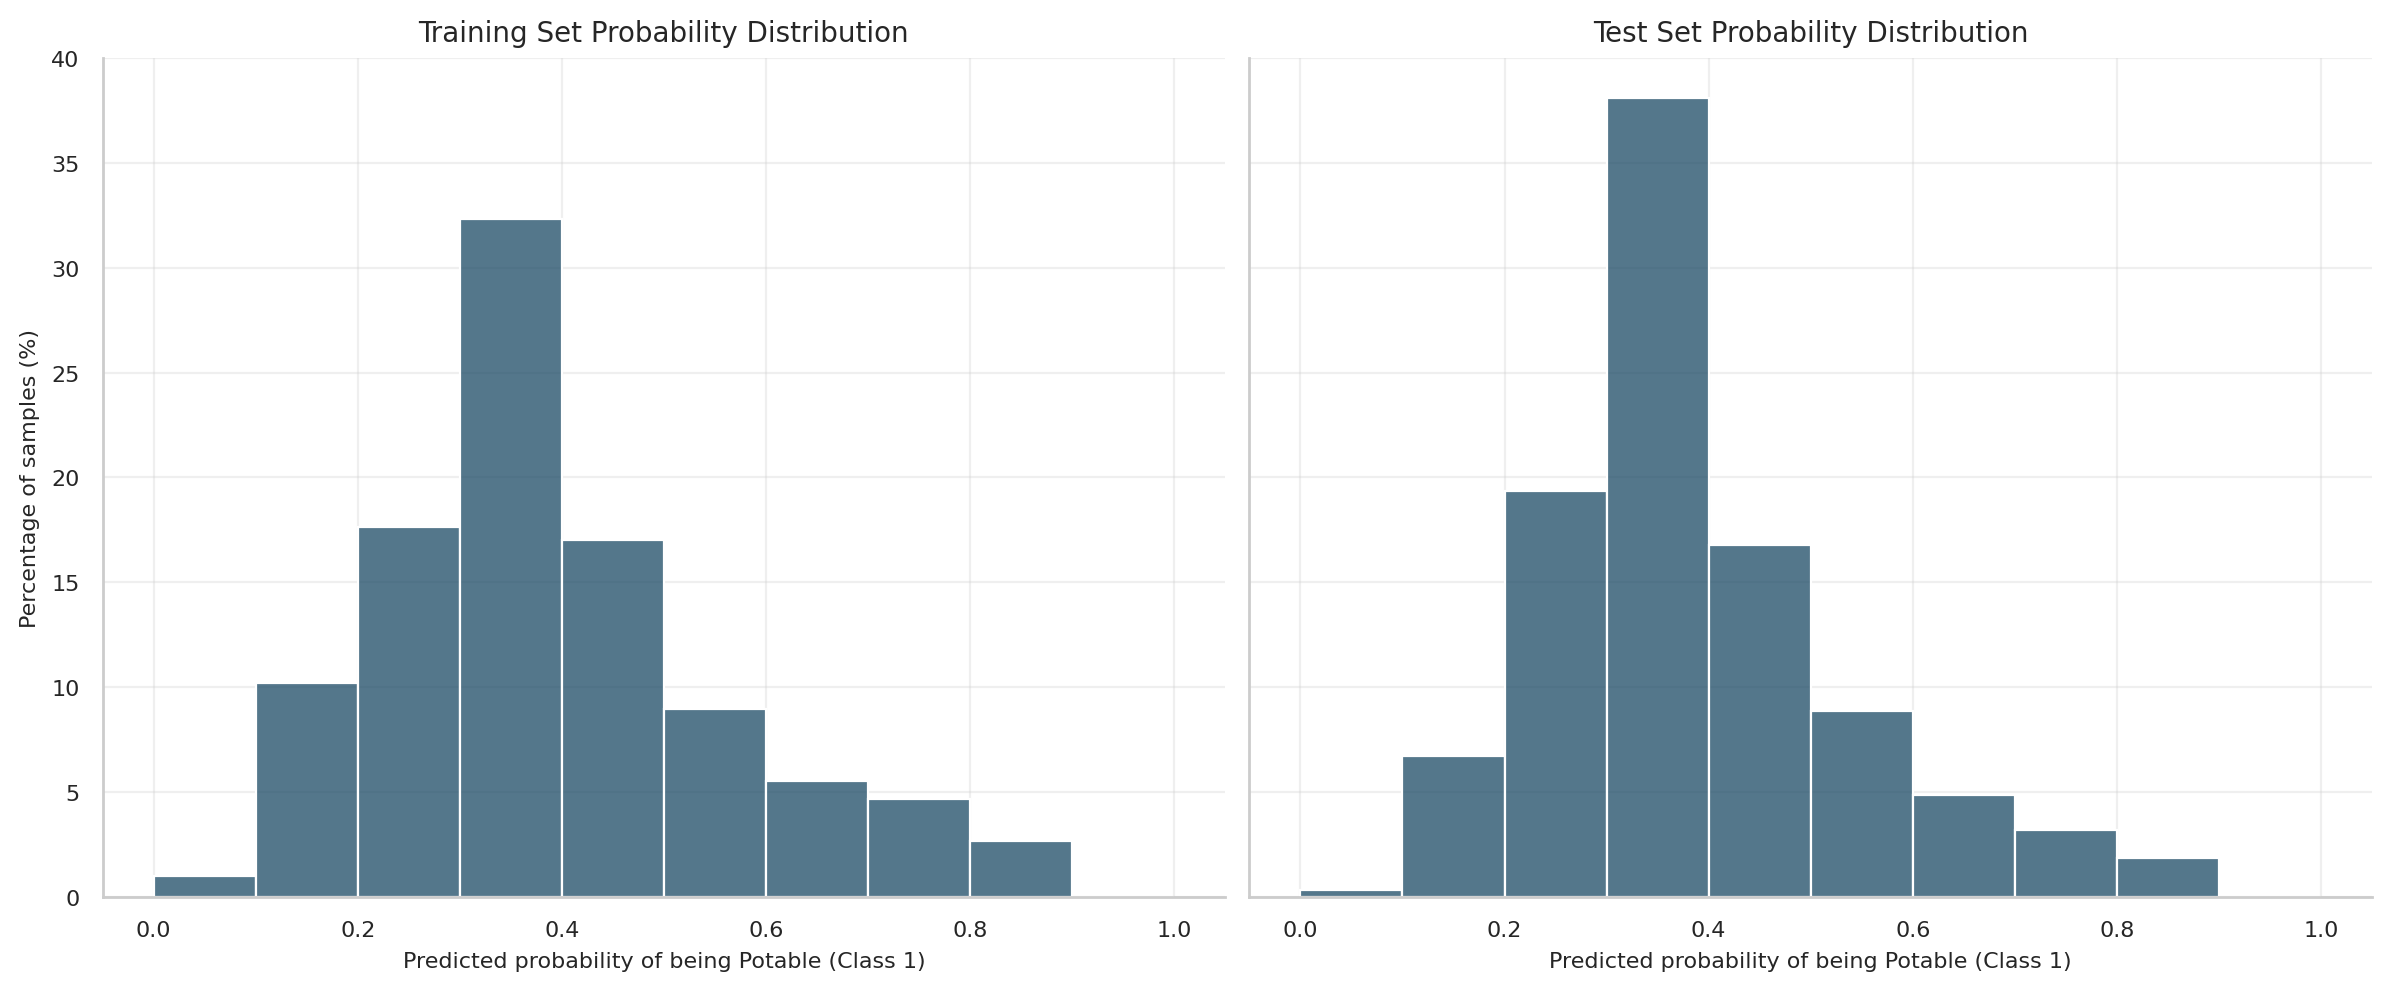


Train Set Confidence Distribution:
High (>0.7): 7.3%
Medium (0.5-0.7): 14.5%
Low (<0.5): 78.2%

Test Set Confidence Distribution:
High (>0.7): 5.0%
Medium (0.5-0.7): 13.7%
Low (<0.5): 81.2%


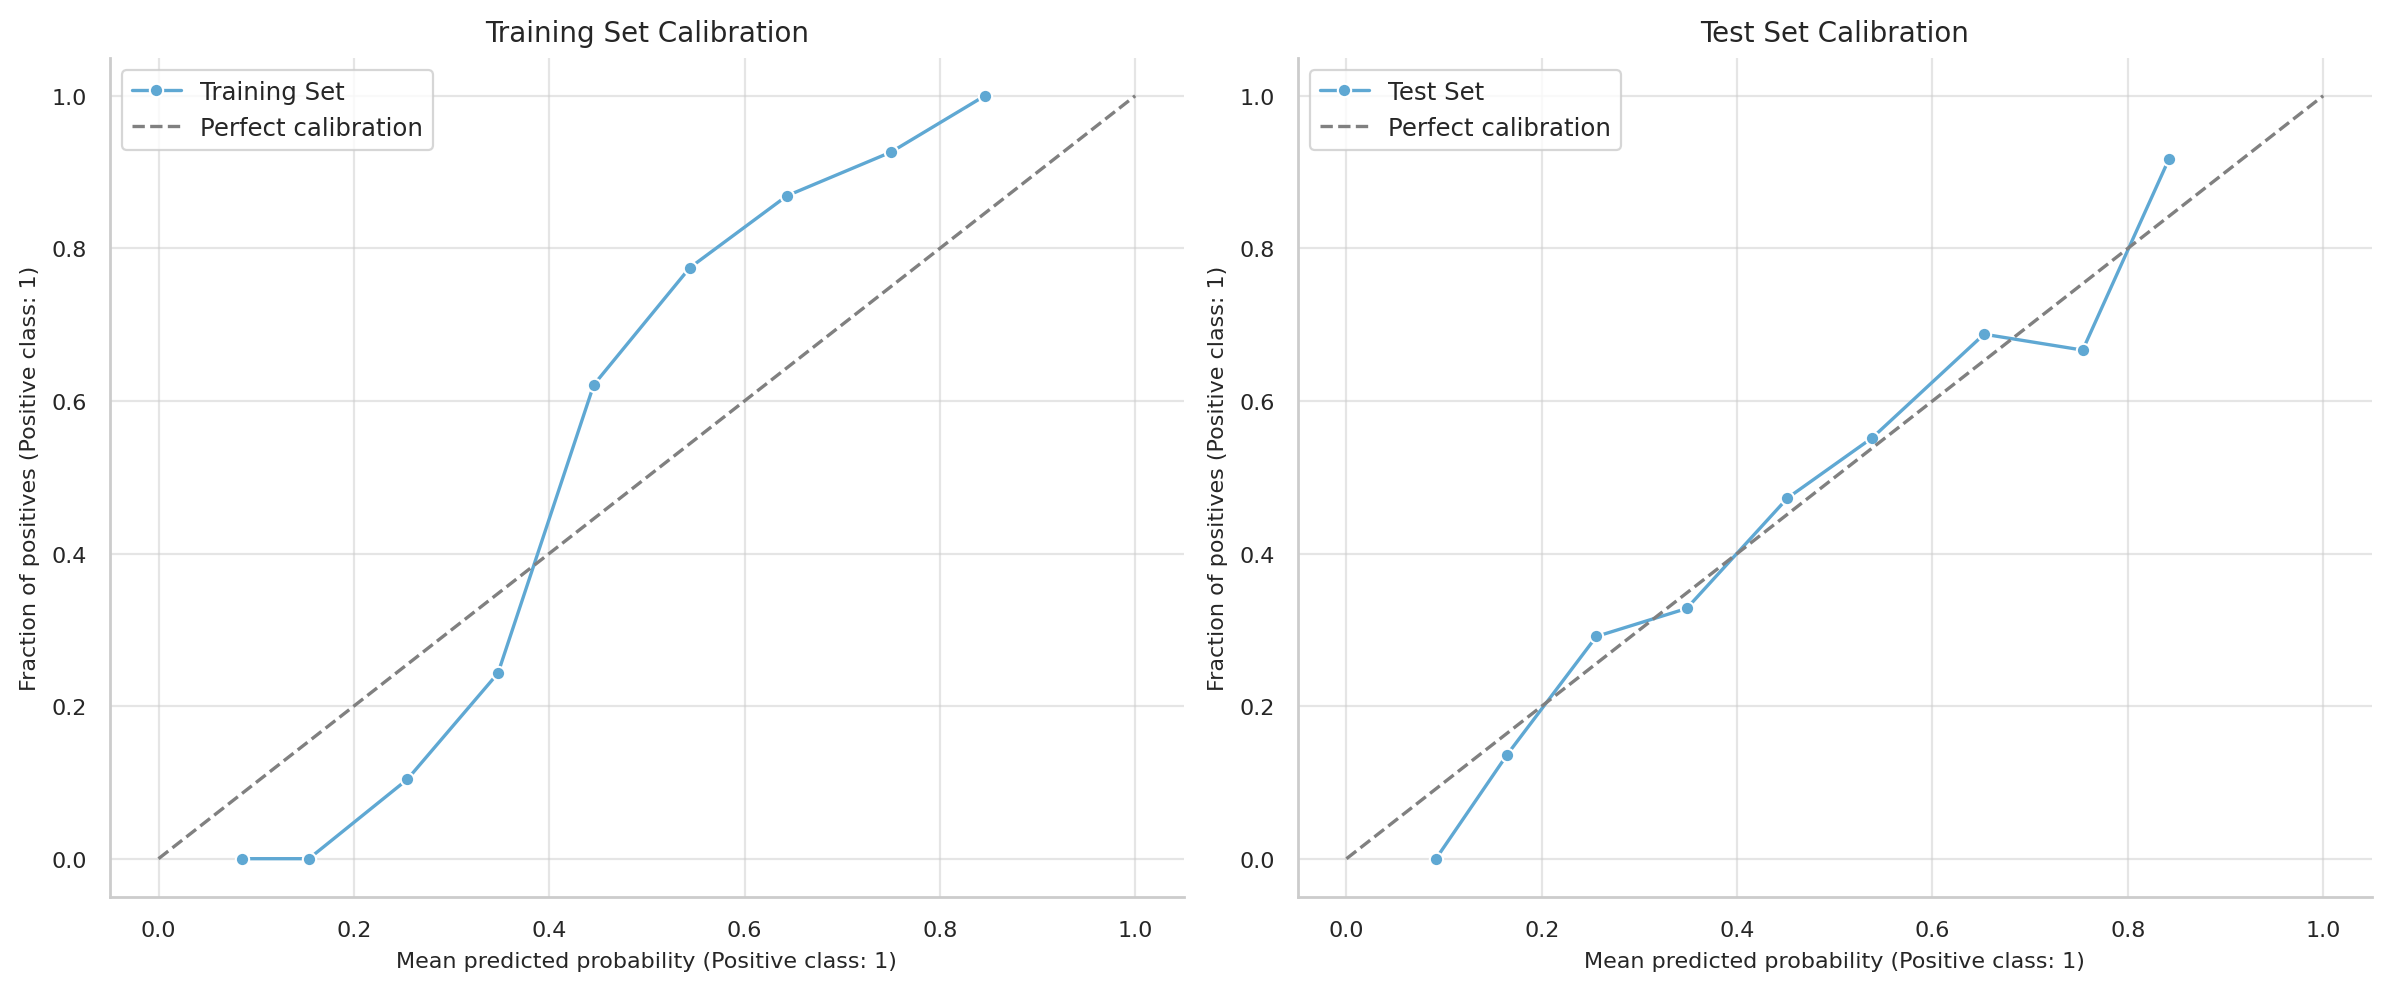

In [21]:
# Fit the model
print("Training model with GridSearchCV...")
random_search.fit(X_train, y_train)

# Retrieve the model with the best hyperparameters found during the random search
best_model = random_search.best_estimator_
print("\nBest parameters found:")
print(random_search.best_params_)

# Model Evaluation
print("\nEvaluating model performance...")
y_train_prob, y_test_prob, performance_metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test)

# Print calibration plots
plot_calibration_curves(y_train, y_train_prob, y_test, y_test_prob)

### Enhanced Model Performance Analysis: Detailed Evaluation
The model's performance reveals several interesting patterns and challenges that merit detailed examination:
#### Metrics and Performance Characteristics:
The model exhibits test accuracy of `66%`, dropping notably from its `77%` training accuracy. This performance gap, while significant, should be viewed in the context of the complex nature of water potability prediction. The model shows particularly strong performance in identifying non-potable water (`89%` `recall` for `class 0`) but struggles considerably with potable water classification (`31%` `recall` for `class 1`).
#### Calibration and Confidence Analysis:
The calibration curves reveal an interestiing pattern: the model demonstrates better calibration on the test set compared to training data. This suggests that while the model's overall accuracy might be lower than desired, its probability estimates are relatively well-aligned with actual outcomes. <br>The confidence distribution is particularly telling:
- Low (<0.5): `81.2%` of predictions have probabilities below `0.5`, indicating the model frequently predicts non-potable water with moderate confidence
- Medium (0.5-0.7): `13.7%` of predictions fall in this range, showing a kind of uncertaintyin water quality
- High(>0.7): Only `5%` of predictions have high confidence, suggesting the model is generally cautious in making very confident predictions

This heavily skewed confidence distribution indicates a model that is appropriately cautious in its predictions, particularly important in a domain where false positives could have serious consequences.

#### Core Challenges:
1. Overfitting Concerns:
The gap between training and test performance (`77%` to `66%`) indicates moderate overfitting, despite the implementation of various regularization techniques.
2. Class Imbalance Impact: The stark difference in performance between classes (`89%` `recall` for **non-potable** vs `30%` for **potable**) indicates that the class balancing strategies employed haven't fully addressed the underlying imbalance issues.
3. Uncertainty Handling: While the high proportion of low-confidence predictions might seem problematic, it actually reflects appropriate uncertainty given the complexity of water quality assessment. The model is conservative about declaring water potable, which is safer but limits utility. 



## OOB Score
For each parameter combination:
1. RobustScaler transforms data
2. KNNImputer fills missing values
3. CalibratedClassifierCV:
   - Creates 5 splits
   - Trains 5 RandomForests with those parameters
   - Calibrates each one

This generates **`5` OOB scores** per parameter set.
<br>`GridSearchCV` then selects the best parameters based on `f1-score`. The `OOB scores` we saw earlier are only from the best parameter combination's final calibrated model.

In [22]:
clf = random_search.best_estimator_.named_steps['clf']
for i in range(5):
    oob_score = clf.calibrated_classifiers_[i].estimator.oob_score_
    print(f"Fold {i+1} OOB Score: {oob_score}")

# Calculate average OOB score across all folds
avg_oob = np.mean([clf.calibrated_classifiers_[i].estimator.oob_score_ for i in range(5)])
print(f"\nAverage OOB Score: {avg_oob}")

Fold 1 OOB Score: 0.6626908396946565
Fold 2 OOB Score: 0.6526717557251909
Fold 3 OOB Score: 0.6550572519083969
Fold 4 OOB Score: 0.6483778625954199
Fold 5 OOB Score: 0.6684160305343512

Average OOB Score: 0.6574427480916031


The average `OOB score` of `~0.66` indicates suboptimal model performance, suggesting **the model correctly predicts only about `66%` of out-of-bag samples**. <br>This relatively low performance, despite extensive parameter tuning and calibration, suggests either inherent complexity in the data that `Random Forest` struggles to capture, or the need to explore additional feature engineering and preprocessing approaches. 

### ROC Curve
**ROC (Receiver Operating Characteristic) and AUC (Area Under the Curve)** are powerful tools for evaluating classification models, especially when dealing with imbalanced datasets like your water quality data.
<br>AUC (Area Under ROC Curve) measures model's ability to rank/order predictions correctly - a model with `AUC=0.60`(for example) will rank a random positive example higher than a random negative example `60%` of the time. Overall accuracy is simpler - just the percentage of correct predictions out of all predictions.

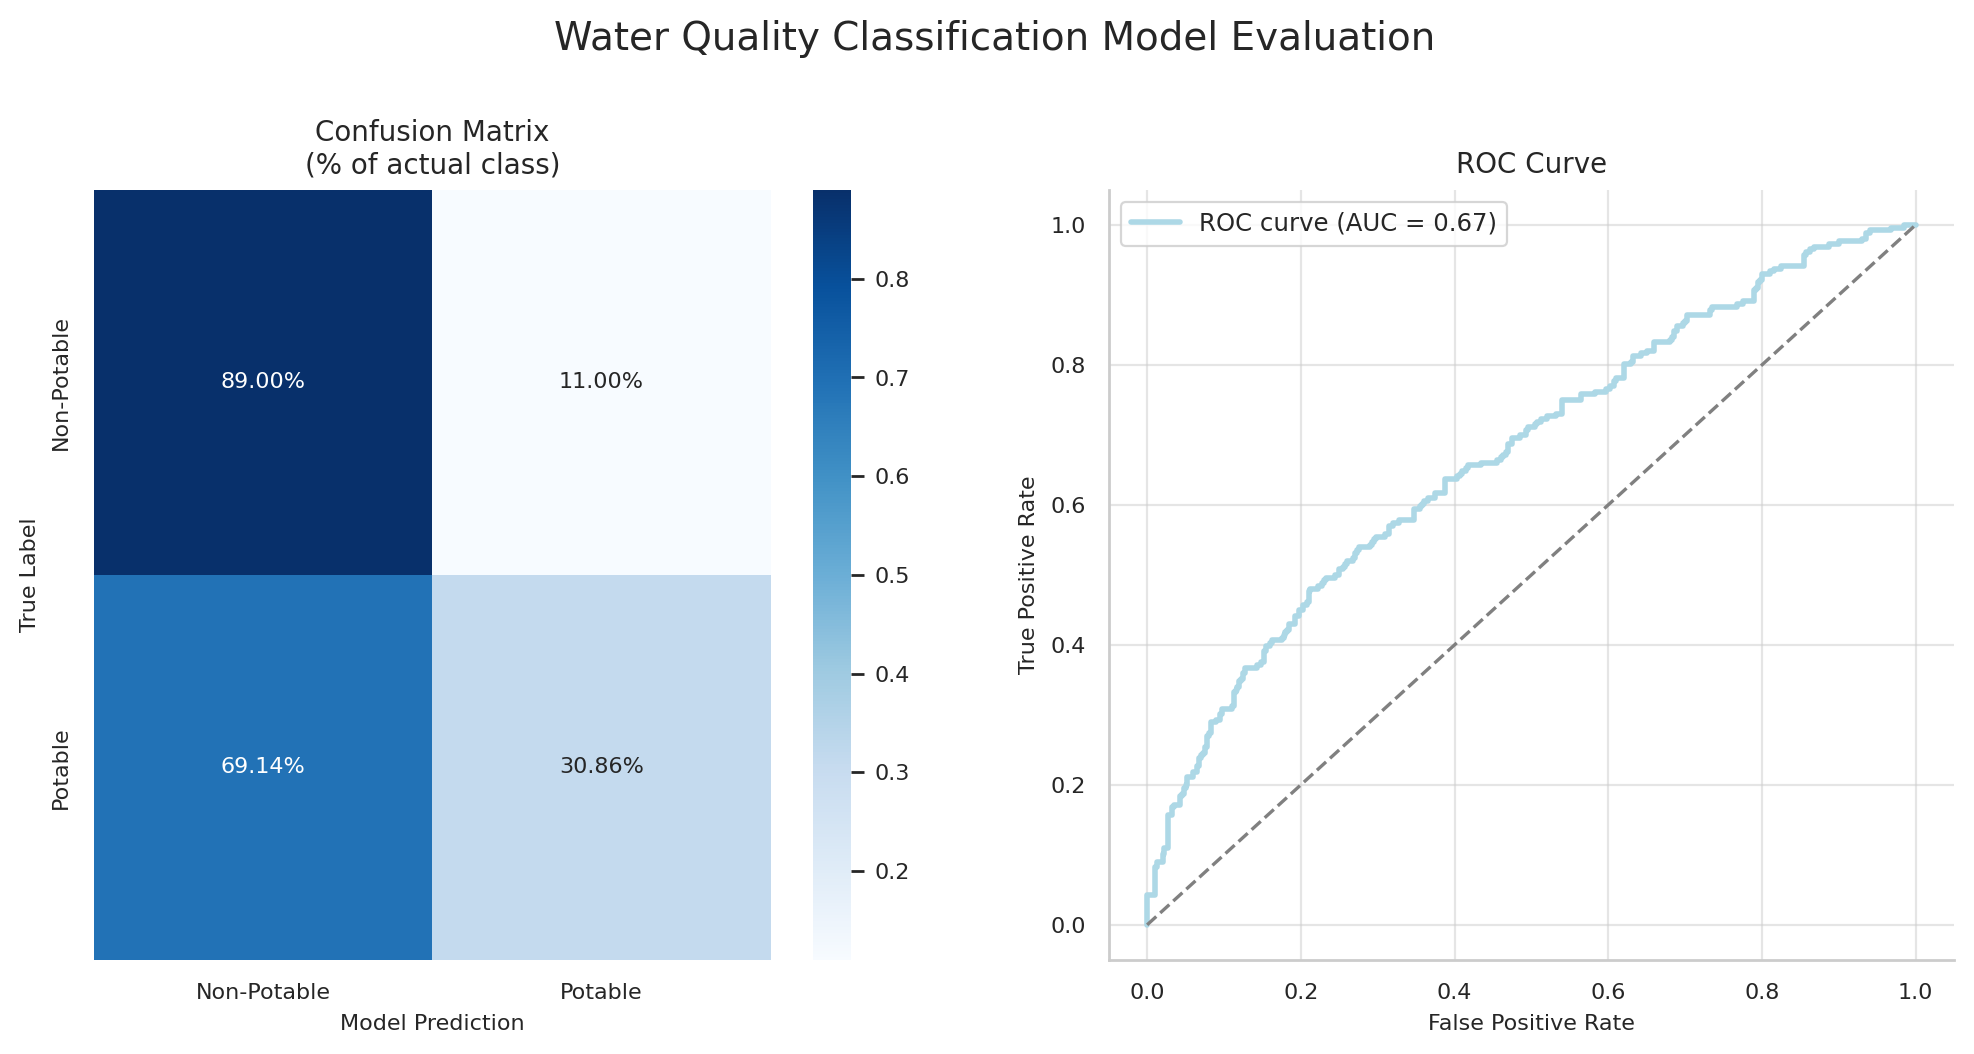


Model Performance Summary:
- ROC-AUC Score: 0.672
- Overall Accuracy: 0.663

Overfitting Analysis:
- Training Score: 0.766
- Testing Score: 0.663
- Score Difference: 0.103


In [23]:
def evaluate_water_quality_model(model, X_train, y_train, X_test, y_test):
    """
    Comprehensive evaluation of water quality classification model.
    Includes ROC-AUC analysis, feature importance, and detailed metrics.
    """
    # Get predictions and probabilities
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:, 1]

    # 1. Confusion Matrix & ROC Curve
    # Create subplots
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Water Quality Classification Model Evaluation', fontsize=14, y=1.05)

    # Confusion Matrix with Percentages
    cm = confusion_matrix(y_test, y_pred_test)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, ax=ax0, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Non-Potable', 'Potable'],
                yticklabels=['Non-Potable', 'Potable'])
    ax0.set(xlabel='Model Prediction', ylabel='True Label')
    ax0.set_title('Confusion Matrix\n(% of actual class)')
    
    # ROC Curve Analysis
    fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
    auc_score = roc_auc_score(y_test, y_prob_test)
    
    ax1.plot(fpr, tpr, color='lightblue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
    ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
    ax1.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend()
    plt.show()
    
    # 5. Model Performance Summary
    print("\nModel Performance Summary:")
    print(f"- ROC-AUC Score: {auc_score:.3f}")
    print(f"- Overall Accuracy: {(y_pred_test == y_test).mean():.3f}")
    
    # Check for overfitting
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print("\nOverfitting Analysis:")
    print(f"- Training Score: {train_score:.3f}")
    print(f"- Testing Score: {test_score:.3f}")
    print(f"- Score Difference: {(train_score - test_score):.3f}")
    
    return {
        'auc_score': auc_score,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred_test)
    }

# Call the function
evaluation_results = evaluate_water_quality_model(
    random_search.best_estimator_,
    X_train, y_train,
    X_test, y_test
)

>#### Consideraions on ROC curve & Confusion Matrix
>The water quality classification model achieves moderate performance with an AUC of `0.672` and overall accuracy of `0.66`. It shows conservative prediction patterns, correctly identifying `89%` of non-potable water but only `31%` of potable, **prioritizing safety** by minimizing false positives.
>
>**Confusion Matrix Interpretation:**
>- `89%`: Of truly non-potable water, model correctly identified this percentage
>- `11%`: Of truly non-potable water, model incorrectly labeled as potable
>- `~69%`: Of truly potable water, model incorrectly labeled as non-potable
>- `~31%`: Of truly potable water, model correctly identified this percentage


## Feature Importance
Using **Permutation Importance** importance instead of built-in feature importance is more reliable as it shows how much model performance drops when each feature is randomly shuffled.
- The values represent percentage decrease in model performance when each feature is permuted.
- Error bars show the stability of importance estimates

In [24]:
# 1. Permutation Importance
# Transform features through pipeline
X_transformed = X_test.copy()
for name, step in list(best_model.named_steps.items())[:-1]:
    X_transformed = step.transform(X_transformed)

# Get feature names after transformations 
features = X_test.columns.tolist()
for name, step in best_model.named_steps.items():
    if hasattr(step, 'get_feature_names_out'):
        features = step.get_feature_names_out(features)

# Now calculate permutation importance on the transformed data
feature_importance = permutation_importance(
    best_model.named_steps['clf'],  # Use just the classifier part
    X_transformed,             # Use transformed data
    y_test,
    n_repeats=10,
    scoring='f1',
    random_state=42
)

# Create DataFrame with matching features and importance scores
permut_importance = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importance.importances_mean * 100,
    'Std': feature_importance.importances_std * 100
}).sort_values('Importance', ascending=False)

# 2. RF importance
rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.named_steps['clf'].calibrated_classifiers_[0].estimator.feature_importances_ * 100
}).sort_values('Importance', ascending=False)

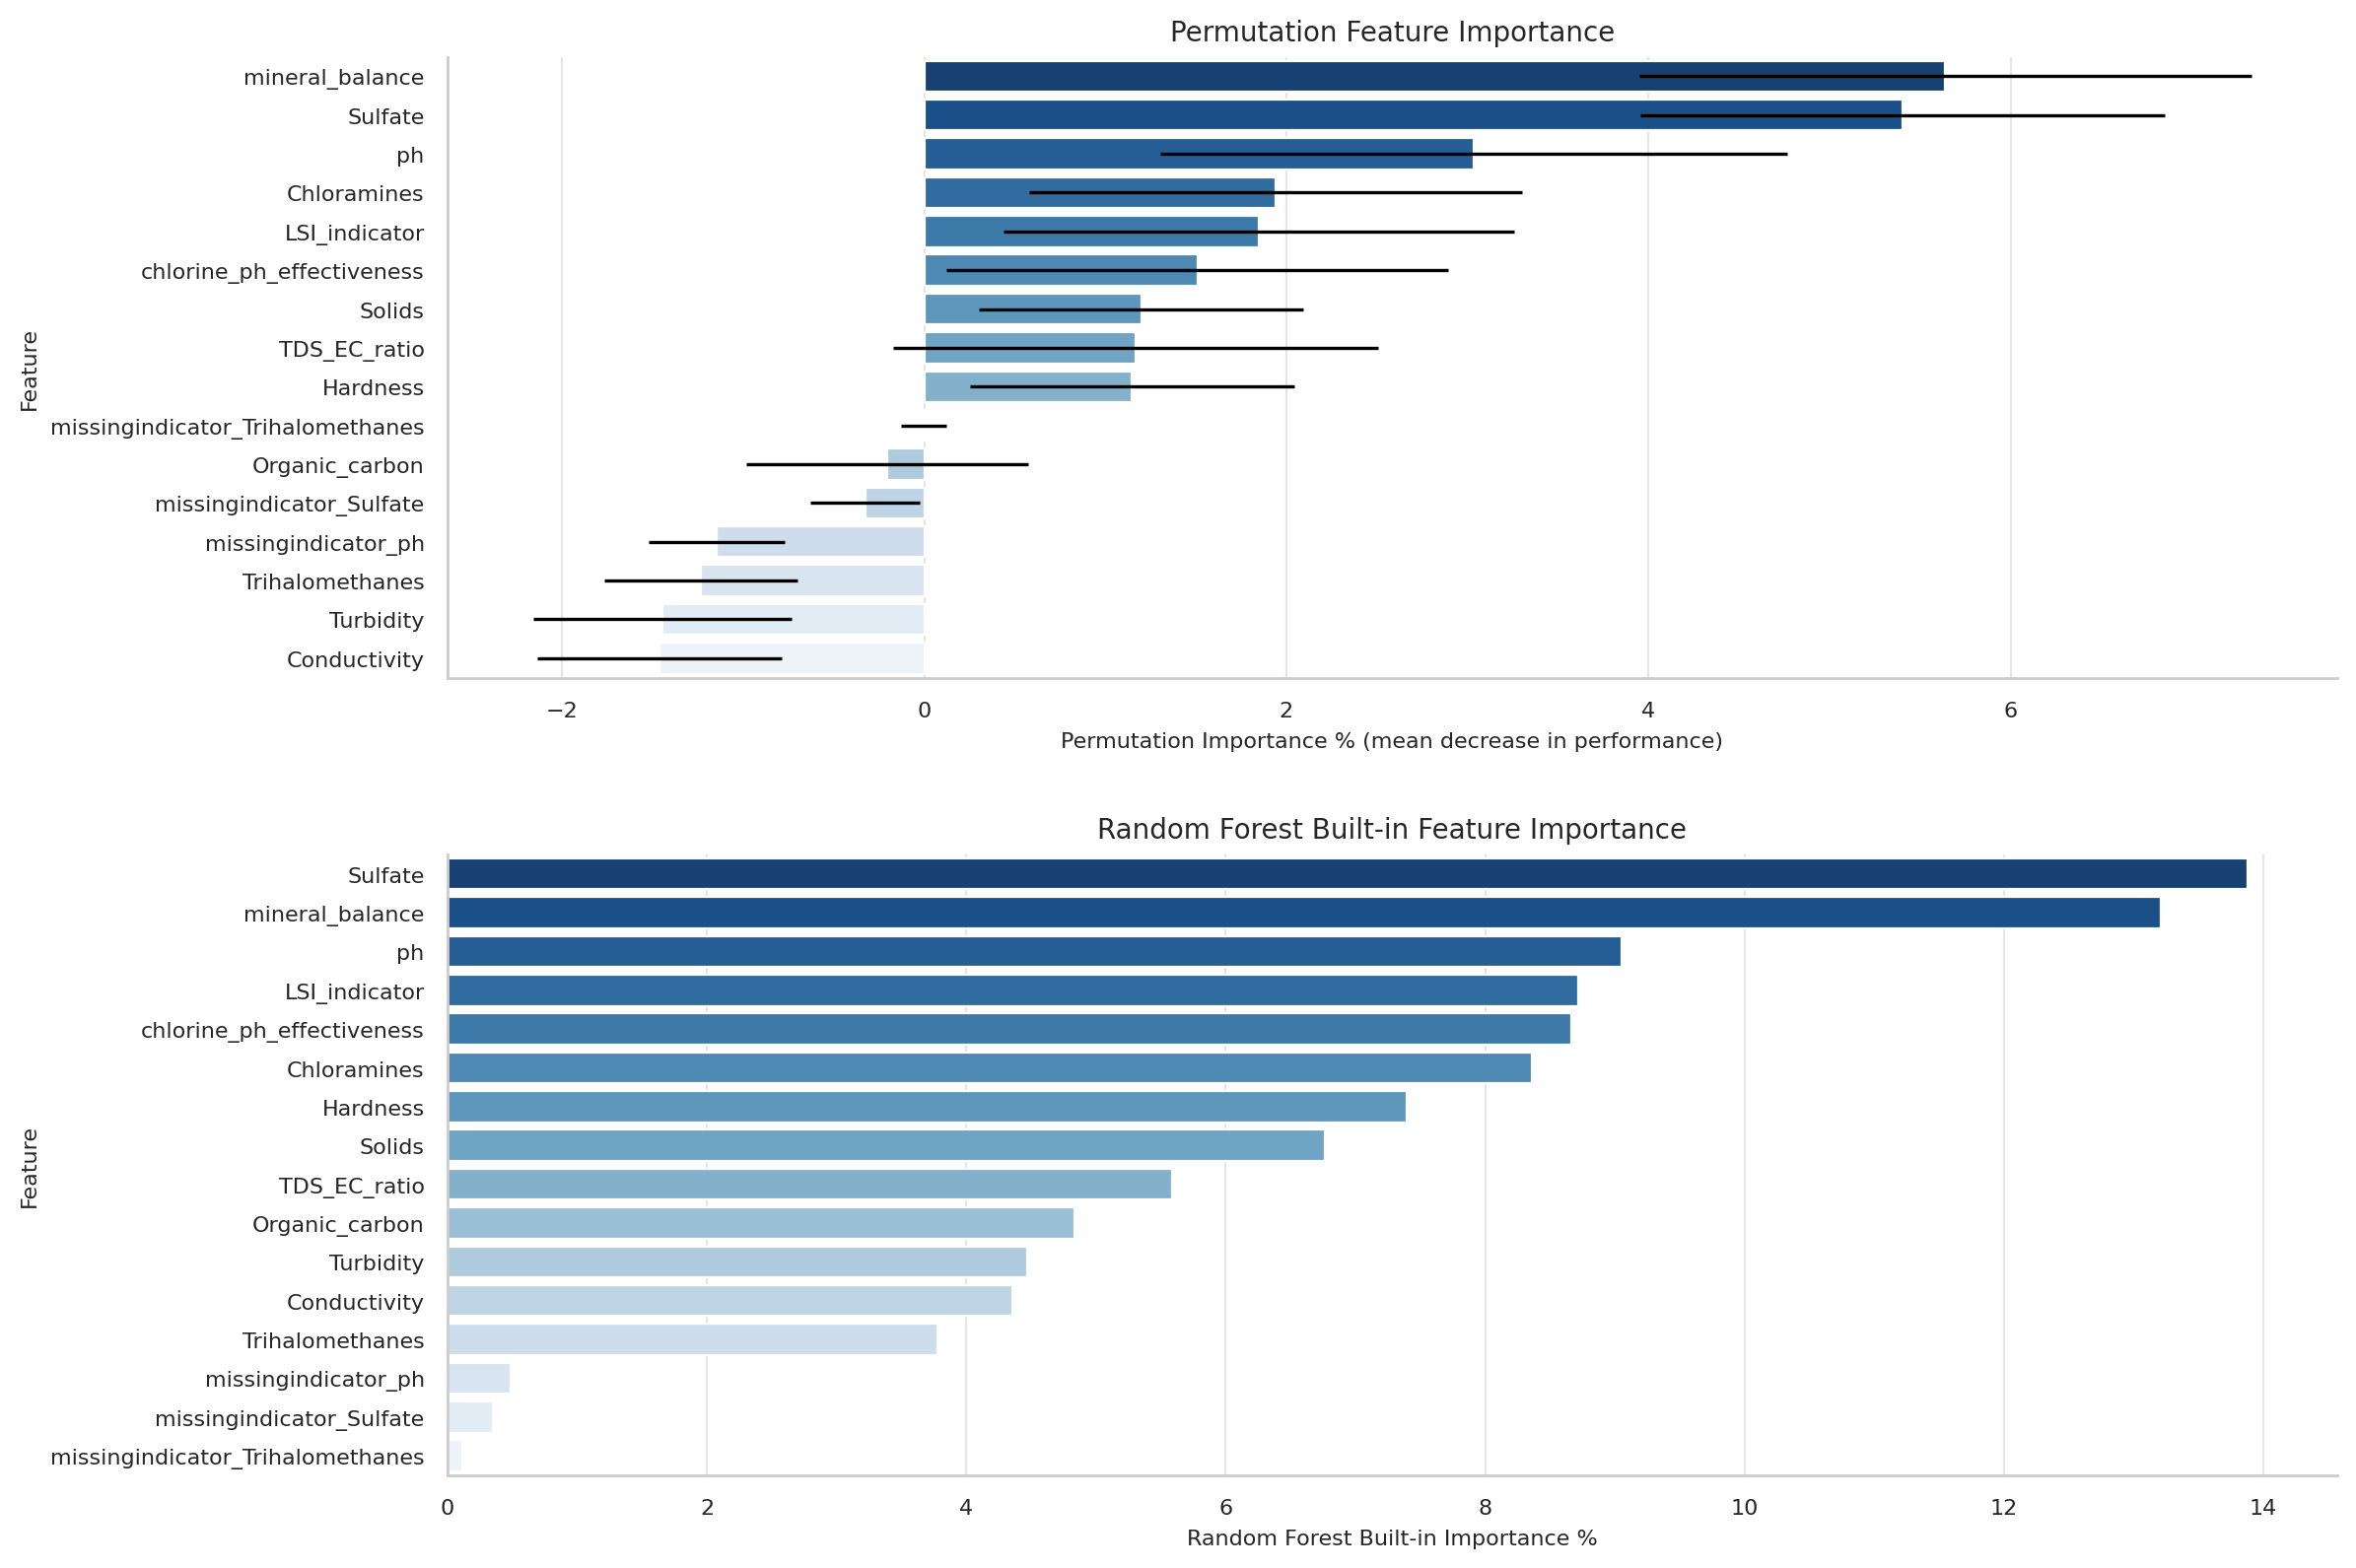

In [25]:
# Plot the importances
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Permutation importance plot
sns.barplot(data=permut_importance, x='Importance', y='Feature', 
           xerr=permut_importance['Std'], palette='Blues_r', 
           capsize=0.2, ax=ax1)
ax1.set_xlabel('Permutation Importance % (mean decrease in performance)')
ax1.set_title('Permutation Feature Importance')

# Random Forest importance plot
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='Blues_r', ax=ax2)
ax2.set_xlabel('Random Forest Built-in Importance %')
ax2.set_title('Random Forest Built-in Feature Importance')

plt.tight_layout(h_pad=3)
plt.show()

>#### Consideraions on Feature Importance
>**Permutation Importance (top plot):**
>- Sulfate and mineral_balance are the strongest predictors, with ~6-8% performance drop when shuffled
>- pH and Chloramines form a second tier of importance
>- Missing value indicators and Conductivity have minimal or negative impact(suggest these features might add noise rather than signal)
>
>**Random Forest Built-in Importance (bottom plot):**
>- Matches permutation results for top features
>- Shows higher importance values (12-14%) for top predictors
>- More optimistic about engineered features (LSI_indicator, chlorine_ph_effectiveness)
>
>Both methods agree on most influential features, with chemical composition (`Sulfate`, `pH`) and derived metrics (`mineral_balance`) being crucial for water potability prediction.
>

## Score Selection: Balancing Performance Trade-offs
When predicting water quality, evaluating metrics like `F1-score` and `Precision` helps balance critical objectives.

**Critical Performance Metrics:**
- `Precision`: What % of our "potable" predictions are correct (***key for safety!***).
- `Recall`: `%` of truly potable water is identified.
- `F1`: Balances precision and recall, ensuring safety without missing potential potable sources (`Precision`-`Recall` trade-off)
- `Accuracy`: Less relevant due to class imbalance.

**Focusing on `F1-score` ensures:**
1. **Safety:** Minimizing false positives with reasonable precision.
2. **Effectiveness:** Addressing `recall` to identify as much potable water as possible.


**This analysis reveals:**
- Balancing safety (`precision`) with utility (`F1`).
- Analyzing metric trade-offs across model configurations enables better parameter tuning and deployment decisions.

**Additional argument for F1:** With significant missing data in key features (`pH`, `Hardness`), `F1-score` provides a balanced metric that accounts for uncertainty in both false positives and negatives, rather than overly focusing on `precision`.

In [26]:
def analyze_model_scores(search_results):
    """
    Analyze cv_results_ from model search (RandomizedSearchCV).
    """
    # Get all results
    results = pd.DataFrame({
        'F1_Score': search_results.cv_results_['mean_test_f1'],
        'Precision': search_results.cv_results_['mean_test_precision'],
        'Parameters': search_results.cv_results_['params'],
        'F1_Rank': search_results.cv_results_['rank_test_f1'],
        'Precision_Rank': search_results.cv_results_['rank_test_precision']
    })
    
    # Sort by F1 score (since that's the primary metric)
    results = results.sort_values('F1_Score', ascending=False)
    
    print("Top 5 Models by F1 Score(metrics for 'class 1'):") # in binary classification, cross-validation metrics 
    for idx, row in results.head(5).iterrows():                # are typically for class 1 (the positive class)
        print(f"\nModel Configuration {idx + 1}:")
        print(f"F1 Score: {row['F1_Score']:.2f} (Rank: {row['F1_Rank']:.0f})")
        print(f"Precision: {row['Precision']:.2f} (Rank: {row['Precision_Rank']:.0f})")
        print("Parameters:", row['Parameters'])
    
    # Analyze trade-offs
    correlation = results['F1_Score'].corr(results['Precision'])
    print(f"\nCorrelation between F1 and Precision: {correlation:.2f}")
    
    return results

# Call the function
results_df = analyze_model_scores(random_search)


Top 5 Models by F1 Score(metrics for 'class 1'):

Model Configuration 30:
F1 Score: 0.43 (Rank: 1)
Precision: 0.65 (Rank: 9)
Parameters: {'clf__estimator__max_depth': 8, 'clf__estimator__min_samples_leaf': 8, 'clf__estimator__min_samples_split': 15, 'clf__estimator__n_estimators': 500, 'imputer__n_neighbors': 20}

Model Configuration 28:
F1 Score: 0.43 (Rank: 2)
Precision: 0.66 (Rank: 1)
Parameters: {'clf__estimator__max_depth': 8, 'clf__estimator__min_samples_leaf': 8, 'clf__estimator__min_samples_split': 15, 'clf__estimator__n_estimators': 500, 'imputer__n_neighbors': 10}

Model Configuration 27:
F1 Score: 0.43 (Rank: 3)
Precision: 0.65 (Rank: 17)
Parameters: {'clf__estimator__max_depth': 8, 'clf__estimator__min_samples_leaf': 8, 'clf__estimator__min_samples_split': 15, 'clf__estimator__n_estimators': 400, 'imputer__n_neighbors': 20}

Model Configuration 48:
F1 Score: 0.43 (Rank: 4)
Precision: 0.64 (Rank: 36)
Parameters: {'clf__estimator__max_depth': 8, 'clf__estimator__min_samples_l

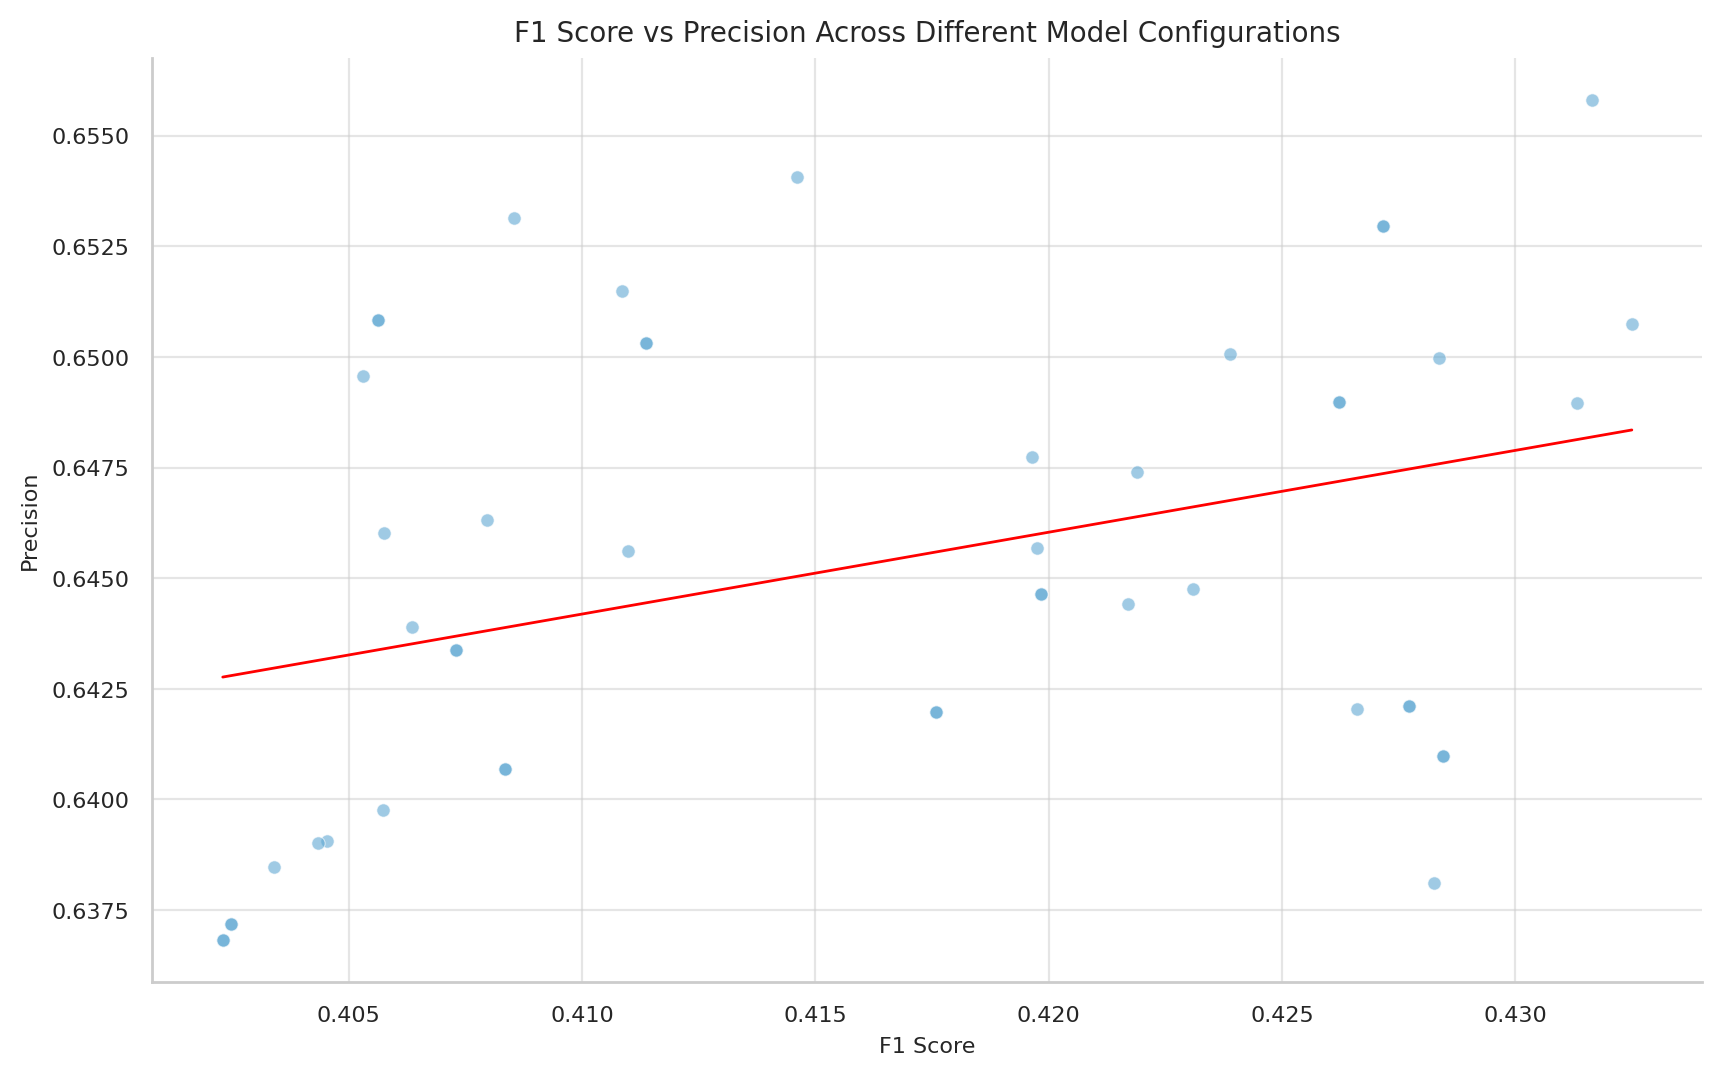

In [27]:
# Visualize the relationship between F1 and Precision
plt.figure(figsize=(10, 6))
# Create a scatter plot with a trendline
sns.scatterplot(data=results_df, x='F1_Score', y='Precision', alpha=0.6)
sns.regplot(data=results_df, x='F1_Score', y='Precision', scatter=False, color='red', line_kws={'linewidth': 1}, ci=None)  # Add trendline without confidence interval
plt.xlabel('F1 Score')
plt.ylabel('Precision')
plt.title('F1 Score vs Precision Across Different Model Configurations')

# Show the plot
plt.show()

>#### Consideraions on Model Configurations
The scatter plot shows a moderate positive correlation (`r=0.35`) between `F1 score` and `precision` across model configurations. The trend line indicates that models with higher `F1 scores` tend to achieve slightly better precision, though there's considerable variance. 
<br>The best performing configurations (top-right) achieve F1 scores around `0.430` with precision up to `0.655`, while weaker models (bottom-left) show `F1` scores around `0.405` with precision around `0.637`.

## Prediction Threshold Analysis
Now the model is trained with `0.5` threshold for predictiond potability. However, we can modify the pipeline adding the custom threshold transformer, and experiment with different threshold.


In [28]:
# Create classifier-function which makes predictions based on custom probability threshold
def predict_with_threshold(model, X, threshold=0.5):
    """
    Make predictions using a custom probability threshold.
    Takes a trained model that can output probabilities
    and converts them to binary predictions using the specified threshold.
    
    Args:
        model: Trained model
        X: Feature matrix for prediction
        threshold: Minimum probability required for positive class (default: 0.5)
    
    Returns:
        numpy array of binary predictions (0 or 1)
    """
    # Get probability estimates from the model
    probabilities = model.predict_proba(X)
    # Convert to binary predictions using threshold
    return (probabilities[:, 1] >= threshold).astype(int)

# Evaluate predictions with different thresholds
def evaluate_threshold_predictions(model, X, y, thresholds=[0.5, 0.55, 0.6, 0.65, 0.7]):
    """
    Evaluate model performance across different probability thresholds.
    
    Args:
        model: Trained model with predict_proba method
        X: Feature matrix
        y: True labels
        thresholds: List of probability thresholds to evaluate
    """
    print("\nEvaluating predictions with different thresholds:")
    print("-" * 60)
    
    for threshold in thresholds:
        # Make predictions with current threshold
        predictions = predict_with_threshold(model, X, threshold)

        print(f"\nThreshold: {threshold}")
        print(f"Accuracy: {accuracy_score(y, predictions):.2f}")
        print(f"Precision: {precision_score(y, predictions):.2f} (% of predicted potable that are truly potable)")
        print(f"Recall: {recall_score(y, predictions):.2f} (% of truly potable water we identified)")
        print(f"F1 Score: {f1_score(y, predictions):.2f}")

# Use these functions with the best model
best_model = random_search.best_estimator_

# Evaluate predictions with different thresholds
evaluate_threshold_predictions(best_model, X_test, y_test)


Evaluating predictions with different thresholds:
------------------------------------------------------------

Threshold: 0.5
Accuracy: 0.66
Precision: 0.64 (% of predicted potable that are truly potable)
Recall: 0.31 (% of truly potable water we identified)
F1 Score: 0.42

Threshold: 0.55
Accuracy: 0.66
Precision: 0.69 (% of predicted potable that are truly potable)
Recall: 0.22 (% of truly potable water we identified)
F1 Score: 0.34

Threshold: 0.6
Accuracy: 0.65
Precision: 0.72 (% of predicted potable that are truly potable)
Recall: 0.18 (% of truly potable water we identified)
F1 Score: 0.29

Threshold: 0.65
Accuracy: 0.65
Precision: 0.78 (% of predicted potable that are truly potable)
Recall: 0.16 (% of truly potable water we identified)
F1 Score: 0.26

Threshold: 0.7
Accuracy: 0.64
Precision: 0.76 (% of predicted potable that are truly potable)
Recall: 0.10 (% of truly potable water we identified)
F1 Score: 0.17


>#### Considerations on Classification Threshold
>Given these considerations, for water safety I would recommend to use default `0.5` threshold.
>The `0.5` threshold gives the best `F1 score (0.42)` because it provides the best balance between precision and recall. 


# 💧Save the Final Model
Saving the model in the wrapper class structure allows to combine two functions: 
1. Getting probabilities
2. Changing the `threshold`(if needed).

The wrapper handles all the complexity internally, providing a clean interface for users.

In [29]:
class WaterQualityModel:
    # Constructor: sets up the model with its threshold
    def __init__(self, model, threshold=0.5):
        self.model = model        # Stores the trained pipeline
        self.threshold = threshold # Stores the decision threshold
    
    # Main prediction method
    def predict(self, X):
        # First get probability estimates from the underlying model
        probabilities = self.model.predict_proba(X)
        # Convert probabilities to binary predictions using threshold
        return (probabilities[:, 1] >= self.threshold).astype(int)

In [30]:
# Create the wrapped model
final_model = WaterQualityModel(best_model, threshold=0.5)

# Evaluate performance
def evaluate_wrapped_model(model, X_test, y_test):
    """
    Evaluate wrapped model performance with detailed metrics.
    
    Args:
        model: WaterQualityModel instance
        X_test: Test features
        y_test: True labels
    """
    # Get predictions
    predictions = model.predict(X_test)
    
    # Calculate metrics
    print("\nModel Performance:")
    print(f"Precision: {precision_score(y_test, predictions):.2f}")
    print(f"Recall: {recall_score(y_test, predictions):.2f}")
    print(f"F1 Score: {f1_score(y_test, predictions):.2f}")
    
    # Detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    
    # You can also access probabilities directly if needed
    probabilities = model.model.predict_proba(X_test)

evaluate_wrapped_model(final_model, X_test, y_test)


Model Performance:
Precision: 0.64
Recall: 0.31
F1 Score: 0.42

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.89      0.76       400
           1       0.64      0.31      0.42       256

    accuracy                           0.66       656
   macro avg       0.66      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



In [31]:
# # Model Deployment
# # Approach 1: Save the complete wrapper class
# import joblib

# # Save
# final_model = WaterQualityModel(best_model, threshold=0.7)
# joblib.dump(final_model, 'water_quality_model.pkl')

# # Load and use
# loaded_model = joblib.load('water_quality_model.pkl')
# predictions = loaded_model.predict(new_data)

# # Approach 2: Save model components separately
# model_package = {
#     'pipeline': best_model,
#     'threshold': 0.7,
#     'metadata': {
#         'creation_date': '2024-01-23',
#         'version': '1.0',
#         'features': feature_names
#     }
# }
# joblib.dump(model_package, 'water_quality_package.pkl')

#### 👩‍🔬 Many thanks to Samy Baladram for his article: 
<br>https://towardsdatascience.com/random-forest-explained-a-visual-guide-with-code-examples-9f736a6e1b3c/